# Transit-Oriented Development in Greater Boston
## 2026 rebuild

In autumn 2024 I built a model for *Statistics for Design* at Northeastern
(Nabeel Gillani) that picked one MBTA station out of 124 as the best place for
a transit-oriented development. It answered **Quincy Center**. That notebook is
in this repository as `2024-original.ipynb`, exactly as it was submitted.

Two years later I came back to it. This notebook is the second pass. It keeps
the question and almost none of the method, and it arrives somewhere different:
not at one station, but at a shortlist whose order depends on who is asking.

**What changed, in one table:**

| | 2024 | 2026 |
| --- | --- | --- |
| Unit of analysis | community, then station | **site** |
| Stages | two, the first discarding seven communities | one |
| Candidates | 8 communities, then 4 stations | **249 sites in 12 communities** |
| Scale | min-max inside the sample | percentile against 3,028 regional sites |
| Shortlist | none, a single winner | **Pareto frontier, 27 sites, no weights** |
| Weights | one set, justified in prose | **five scenarios, each a stated position** |
| Demand vintage | Fall 2023 | Fall 2025, with a 2017–2025 panel behind it |
| Output | Quincy Center, 82.40 | three winners, depending on the question |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA = 'data/'
FIG = 'figures/'
os.makedirs(FIG, exist_ok=True)

# One palette for every figure in the notebook, so the charts read as a set
# rather than as thirteen separate decisions.
INK, MUTE, FAINT = '#14120C', '#6E685A', '#E2D7BE'
ACCENT, ACCENT2 = '#D03B00', '#3E7C8A'
LINE_COLOR = {'Red': '#DA291C', 'Orange': '#ED8B00', 'Blue': '#003DA5',
              'Green': '#00843D', 'Mattapan': '#DA291C'}

# The case study that shows these charts is set in Instrument Sans, so the
# charts are too. The files travel with the repository (SIL Open Font License),
# which also means the notebook renders the same on a machine that has neither
# installed. Missing folder falls back to whatever matplotlib has.
import glob
for _f in glob.glob('fonts/*.ttf'):
    mpl.font_manager.fontManager.addfont(_f)
INSTALLED = {f.name for f in mpl.font_manager.fontManager.ttflist}
SANS = 'Instrument Sans' if 'Instrument Sans' in INSTALLED else 'DejaVu Sans'
MONO = 'IBM Plex Mono' if 'IBM Plex Mono' in INSTALLED else 'DejaVu Sans Mono'
print('charts set in:', SANS)

mpl.rcParams.update({
    'font.family': SANS, 'font.sans-serif': [SANS], 'font.monospace': [MONO],
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': MUTE, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTE, 'ytick.color': MUTE,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': FAINT, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'font.size': 11, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.titlepad': 12, 'figure.dpi': 100, 'savefig.bbox': 'tight',
})


SRC_MAPC = 'MAPC Rethinking the Retail Strip Sites, Jan 2022'
SRC_RIDE = 'MBTA rail ridership, Fall 2025'
SRC_BOTH = f'{SRC_MAPC}  ·  {SRC_RIDE}'


def save(name, dpi=300, source=None):
    # A square-ish figure renders narrower than a wide one at the same dpi, and
    # the viewer asks every picture for the same 3200 pixels. Those get their
    # own number rather than a bigger figsize, which would change the layout.
    #
    # `source` is accepted and printed only in the notebook's own output, not
    # drawn into the image. Fifteen charts each carrying the same two-line
    # provenance is fifteen copies of one sentence; the case study states it
    # once in its credits and the repository README lists every file.
    if source:
        print('source:', source)
    plt.savefig(f'{FIG}{name}.png', dpi=dpi)
    plt.show()


def money(x, _=None):
    return f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'


thousands = FuncFormatter(lambda x, _: f'{x:,.0f}')

charts set in: Instrument Sans


## 01. Eligibility is a filter, not a score

The 2024 model scored communities on five indicators and kept the winner. That
conflates two different questions. Whether a community is *eligible* — does the
zoning law apply, is there a rapid transit station — is a yes or no. Whether a
*site* is suitable is a matter of degree. Mixing them into one weighted sum let
a community's average land price stand in for the price of the parcel you would
actually buy.

So eligibility is applied here as a filter and nothing else.

source: Commonwealth of Massachusetts, MBTA Communities compliance data


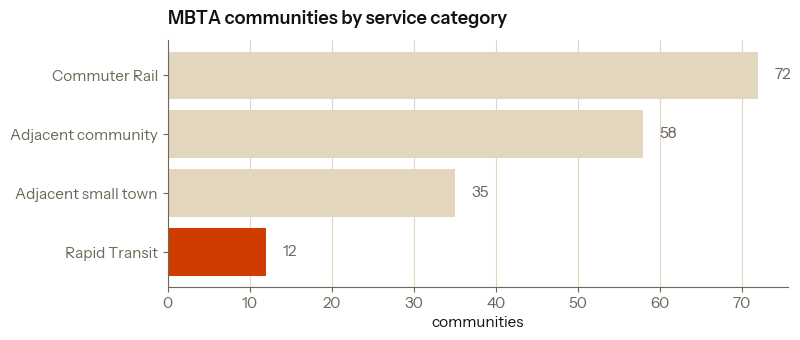

Braintree, Brookline, Cambridge, Chelsea, Everett, Malden, Medford, Milton, Newton, Quincy, Revere, Somerville


In [2]:
com = pd.read_csv(DATA + 'MBTA Communities.csv')
RTC = sorted(com.loc[com.community_category == 'Rapid Transit', 'community'])

counts = com.community_category.value_counts()
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(counts.index[::-1], counts.values[::-1],
               color=[ACCENT if c == 'Rapid Transit' else FAINT for c in counts.index[::-1]])
for b, v in zip(bars, counts.values[::-1]):
    ax.text(v + 2, b.get_y() + b.get_height() / 2, str(v), va='center', color=MUTE)
ax.set_title('MBTA communities by service category')
ax.set_xlabel('communities')
ax.grid(axis='y', visible=False)
save('01-eligibility', source='Commonwealth of Massachusetts, MBTA Communities compliance data')
print(', '.join(RTC))

## 02. Candidates are sites, because the decision is a site

MAPC's *Rethinking the Retail Strip* inventory carries 3,028 redevelopment
sites across Greater Boston, each with its own land value, buildable area and
the transit station it sits beside. The 2024 model used two of its 64 columns
and averaged them up to the municipality. This one keeps the site.

It also removes a step. The 2024 screening reverse-geocoded 124 stations
through Nominatim to get postcodes and intersected those with community
postcodes. This dataset already names both the municipality and the station, so
the geocoding is unnecessary — and it was lossy: Medford fell out of the 2024
frame entirely.

In [3]:
s = pd.read_csv(DATA + 'mapc.rethinking_retail_sites.csv', low_memory=False)
s['ppa'] = s.land_value / s.sitearea_a

steps = [('MAPC sites, region-wide', len(s))]
site = s[s.municipal.isin(RTC)].copy()
steps.append(('in a Rapid Transit Community', len(site)))
site = site[site.stattyp == 'Rapid Transit']
steps.append(('beside a rapid transit station', len(site)))
# MAPC's own station label, kept for the cross-check further down. It is not
# what the model joins on.
site['mapc_station'] = site.statname.str.replace(' Glx', '', regex=False).str.strip()

### Demand, measured in the most recent autumn

Section 06 shows why the vintage matters: Fall 2023, which the 2024 model used,
was a trough. Fall 2025 is the freshest release. It reports ridership by hour
rather than by service-planning period, so the peak window has to be defined
here — and the definition is checked against the period-based Fall 2024 file
rather than asserted.

In [4]:
def load_ridership(fn):
    d = pd.read_csv(DATA + fn, encoding='utf-8-sig', low_memory=False)
    d.columns = [c.lower() for c in d.columns]
    d['day_type'] = d.day_type_name.str.lower()
    d['flow'] = d.average_ons + d.average_offs
    return d


f25 = load_ridership('Fall_2025_MBTA_Rail_Ridership_by_Hour_RouteLine_and_Stop.csv')
f24 = load_ridership('Fall_2024_MBTA_Rail_Ridership_by_SDP_Time_Period_Route_Line_and_Stop.csv')
f25['hour'] = f25.hour_of_service.str.slice(0, 2).astype(int)

wd24 = f24[f24.day_type == 'weekday']
peak24 = (wd24[wd24.time_period_name.str.contains('AM_PEAK|PM_PEAK', na=False)]
          .groupby('stop_name').flow.sum() / wd24.groupby('stop_name').flow.sum())

wd25, we25 = f25[f25.day_type == 'weekday'], f25[f25.day_type.isin(['saturday', 'sunday'])]
wd_flow = wd25.groupby('stop_name').flow.sum()

trial = {}
for am, pm in [((7, 8), (16, 17)), ((7, 8, 9), (16, 17, 18)),
               ((6, 7, 8), (15, 16, 17, 18)), ((7, 8), (17, 18))]:
    hrs = set(am) | set(pm)
    ps = wd25[wd25.hour.isin(hrs)].groupby('stop_name').flow.sum() / wd_flow
    trial[f'{min(am)}-{max(am)+1}, {min(pm)}-{max(pm)+1}'] = \
        pd.concat([ps, peak24], axis=1).dropna().corr().iloc[0, 1]
trial = pd.Series(trial).sort_values(ascending=False)
print('agreement with the Fall 2024 period definition:')
print(trial.round(3).to_string())

PEAK_HOURS = {7, 8, 9, 16, 17, 18}
we_flow = we25.groupby('stop_name').flow.sum() / 2
station = pd.DataFrame({
    'daily': (wd_flow * 5 + we_flow * 2) / 7,
    'weekend': we_flow,
    'peak_share': wd25[wd25.hour.isin(PEAK_HOURS)].groupby('stop_name').flow.sum() / wd_flow,
    'wkday_wknd': wd_flow / we_flow,
    'line': f25.groupby('stop_name').route_id.agg(lambda x: sorted(set(x))[0]),
})
station['line'] = station.line.str.split('-').str[0]

# Each parcel is assigned to the nearest station that has Fall 2025 ridership,
# not to the station MAPC named. Names go stale: seven Somerville parcels are
# inventoried under `Washington Street`, which in the current MBTA feed is a
# Green Line B stop six kilometres away in Brighton, and joining on the name
# gave those parcels Brighton's ridership. Coordinates do not go stale.
coords = pd.read_csv(DATA + 'boston_subway_stations_info.csv')
coords = coords[coords.stop_name.isin(station.index)].reset_index(drop=True)
KM_PER_DEG = 111.32
gap = np.hypot(
    (site.long.to_numpy()[:, None] - coords.position_x.to_numpy())
    * KM_PER_DEG * np.cos(np.radians(site.lat.to_numpy()[:, None])),
    (site.lat.to_numpy()[:, None] - coords.position_y.to_numpy()) * KM_PER_DEG)
site['station'] = coords.stop_name.to_numpy()[gap.argmin(1)]
site['station_km'] = gap.min(1)
print('nearest station differs from the MAPC label at',
      int((site.station != site.mapc_station).sum()), 'of', len(site), 'sites;',
      'farthest walk', round(site.station_km.max(), 2), 'km')

# Half a mile is the catchment transit-oriented development is usually defined
# over, and it is as far as attributing a station's ridership to a parcel can be
# defended. Seven sites sit beyond it: five in Medford inventoried against a
# Green Line extension station that was never built, two in Milton.
HALF_MILE_KM = 0.805
site = site[site.station_km <= HALF_MILE_KM]
steps.append(('within a half-mile walk of a station', len(site)))

site = site.join(station.drop(columns='line'), on='station')
site['line'] = site.station.map(station.line)

n = len(site)
site = site[(site.ppa > 0) & (site.buildar_ac > 0)]
steps.append(('land value and buildable area above zero', len(site)))
site = site[(site.excl_p < 50) & (site.fz100_p < 50)]
steps.append(('under half excluded land or flood zone', len(site)))

agreement with the Fall 2024 period definition:
7-10, 16-19    0.958
7-9, 17-19     0.935
7-9, 16-18     0.929
6-9, 15-19     0.848
nearest station differs from the MAPC label at 39 of 285 sites; farthest walk 2.03 km


source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


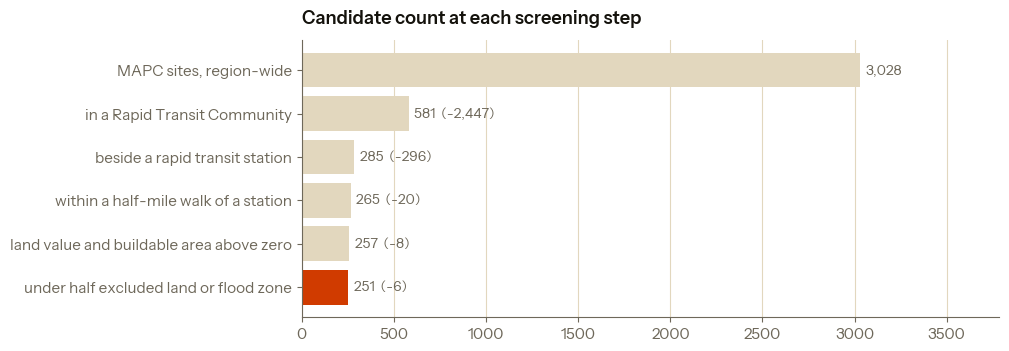

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
labels = [a for a, _ in steps][::-1]
vals = [b for _, b in steps][::-1]
bars = ax.barh(labels, vals, color=[ACCENT] + [FAINT] * (len(vals) - 1))
for b, v, prev in zip(bars, vals, vals[1:] + [None]):
    drop = '' if prev is None else f'  ({v - prev:+,})'
    ax.text(v + 30, b.get_y() + b.get_height() / 2, f'{v:,}{drop}', va='center',
            color=MUTE, fontsize=10)
ax.set_title('Candidate count at each screening step')
ax.set_xlim(0, max(vals) * 1.25)
ax.grid(axis='y', visible=False)
save('02-screening', source=SRC_BOTH)

### Where the candidates are

Every other figure here plots sites in indicator space, which says how a site
scores and nothing about where it is. This one is the reference: nine
communities, four lines, and the stations the write-up ends up naming.

There is no basemap. The MAPC inventory covers the whole region and its sites
only exist on land, so the regional cloud behind the candidates does the work
a coastline would: it shows where the built-up ground is and leaves the
harbour empty.

source:

 MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


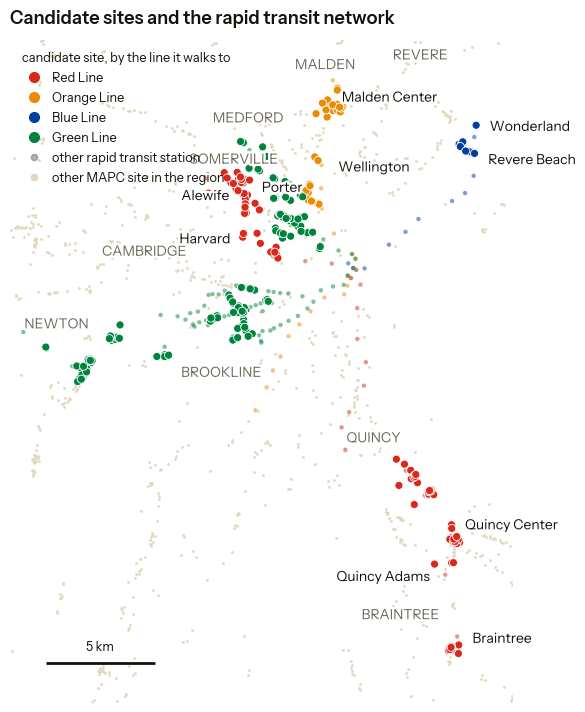

In [6]:
import matplotlib.patheffects as pe

# Stations the write-up names in its text or its tables. A reader meeting
# `Malden Center, 10.0 ac` in a table has no way to place it.
LOCATE = {'Malden Center': (11, 5), 'Wellington': (12, -2),
          'Revere Beach': (11, -7), 'Wonderland': (11, 7),
          'Harvard': (-11, -4), 'Alewife': (0, -13), 'Porter': (11, 7),
          'Quincy Center': (11, 2), 'Quincy Adams': (-11, -2),
          'Braintree': (11, -2)}
assert set(LOCATE) <= set(site.station), set(LOCATE) - set(site.station)

# Community names, placed by hand: an automatic centroid puts Cambridge,
# Somerville and Medford on top of one another in the inner core.
TOWNS = {'Malden': (-71.075, 42.443), 'Revere': (-71.022, 42.447),
         'Medford': (-71.118, 42.421), 'Somerville': (-71.126, 42.404),
         'Cambridge': (-71.176, 42.366), 'Brookline': (-71.133, 42.316),
         'Newton': (-71.225, 42.336), 'Quincy': (-71.048, 42.289),
         'Braintree': (-71.033, 42.216)}
assert set(TOWNS) == set(site.municipal), set(TOWNS) ^ set(site.municipal)

HALO = [pe.withStroke(linewidth=3.4, foreground='white')]
PAD = 0.020
x0, x1 = site.long.min() - PAD, site.long.max() + PAD
y0, y1 = site.lat.min() - PAD, site.lat.max() + PAD

fig, ax = plt.subplots(figsize=(7.8, 8.6))

reg = s[s.long.between(x0, x1) & s.lat.between(y0, y1)]
ax.scatter(reg.long, reg.lat, s=4, color=FAINT, lw=0, zorder=1)

net = coords[coords.position_x.between(x0, x1) & coords.position_y.between(y0, y1)]
ax.scatter(net.position_x, net.position_y, s=10, lw=0, zorder=2, alpha=0.5,
           color=[LINE_COLOR.get(r, MUTE) for r in net.route_id])

ax.scatter(site.long, site.lat, s=34, lw=0.6, edgecolor='white', zorder=4,
           color=[LINE_COLOR.get(l, MUTE) for l in site.line])

for town, (tx, ty) in TOWNS.items():
    ax.text(tx, ty, town.upper(), ha='center', va='center', fontsize=10,
            color=MUTE, zorder=5, path_effects=HALO)

seen = coords.drop_duplicates('stop_name').set_index('stop_name')
for nm, (dx, dy) in LOCATE.items():
    r = seen.loc[nm]
    ax.annotate(nm, (r.position_x, r.position_y), textcoords='offset points',
                xytext=(dx, dy), fontsize=10, color=INK, zorder=6,
                ha='left' if dx > 0 else 'right' if dx < 0 else 'center',
                va='center', path_effects=HALO)

# A scale bar: nothing else on a coordinate plot says how far apart any of this
# is, and the half-mile screening radius needs something to be read against.
SCALE_KM = 5
deg = SCALE_KM / (111.320 * np.cos(np.radians(site.lat.mean())))
bx, by = x0 + PAD, y0 + PAD * 0.8
ax.plot([bx, bx + deg], [by, by], color=INK, lw=2, zorder=6, solid_capstyle='butt')
ax.text(bx + deg / 2, by + 0.004, f'{SCALE_KM} km', ha='center', va='bottom',
        fontsize=9, color=INK, zorder=6)

handles = [plt.Line2D([], [], ls='', marker='o', ms=7, color=c, label=f'{k} Line')
           for k, c in LINE_COLOR.items() if k != 'Mattapan']
handles += [plt.Line2D([], [], ls='', marker='o', ms=4.5, color=MUTE, alpha=0.5,
                       label='other rapid transit station'),
            plt.Line2D([], [], ls='', marker='o', ms=4.5, color=FAINT,
                       label='other MAPC site in the region')]
ax.legend(handles=handles, frameon=False, fontsize=9.2, loc='upper left',
          labelspacing=0.55, handletextpad=0.4, alignment='left',
          title='candidate site, by the line it walks to', title_fontsize=9.2)

ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
# Degrees of longitude are shorter than degrees of latitude this far north, so
# the aspect has to correct for it or the region comes out stretched east-west.
ax.set_aspect(1 / np.cos(np.radians(site.lat.mean())))
ax.set_title('Candidate sites and the rapid transit network')
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
# A taller figure than most here, so 300 dpi lands under the 2600px the page
# asks of a prose-width picture. The map is the one figure a reader zooms into.
save('16-map', dpi=450, source=SRC_BOTH)

## 03. What each indicator looks like before anything is done to it

Four quantities, each in its own units. Land price and buildable area are
properties of the parcel; ridership and peak share are properties of the
station it sits beside. Plotting them first is not decoration: three of the
four are heavily skewed, which is exactly the shape that makes a mean
misleading and a percentile honest.

source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


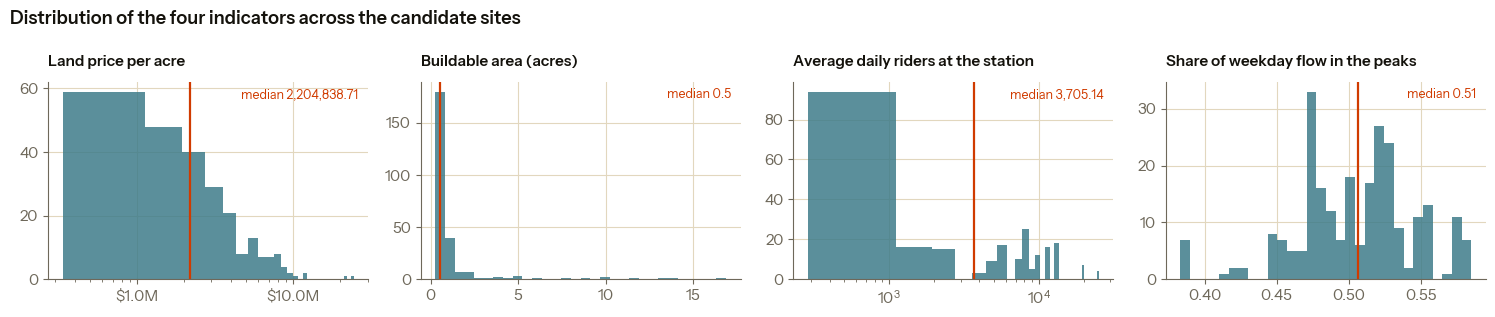

In [7]:
IND = ['ppa', 'buildar_ac', 'daily', 'peak_share']
LOWER_IS_BETTER = {'ppa', 'peak_share'}
NICE = {'ppa': 'Land price per acre', 'buildar_ac': 'Buildable area (acres)',
        'daily': 'Average daily riders at the station',
        'peak_share': 'Share of weekday flow in the peaks',
        'jobs45tr': 'Jobs reachable in 45 minutes'}

fig, axes = plt.subplots(1, len(IND), figsize=(3.75 * len(IND), 3.2))
for ax, c in zip(axes, IND):
    v = site[c]
    ax.hist(v, bins=30, color=ACCENT2, alpha=0.85)
    ax.axvline(v.median(), color=ACCENT, lw=1.6)
    ax.set_title(NICE[c], fontsize=11)
    ax.text(0.97, 0.92, f'median {v.median():,.2f}'.rstrip('0').rstrip('.'),
            transform=ax.transAxes, ha='right', color=ACCENT, fontsize=9)
    if c in ('ppa', 'daily'):
        ax.set_xscale('log')
    if c == 'ppa':
        ax.xaxis.set_major_formatter(FuncFormatter(money))
fig.suptitle('Distribution of the four indicators across the candidate sites',
             x=0.005, ha='left', fontweight='bold', fontsize=13)
plt.tight_layout()
save('03-distributions', source=SRC_BOTH)

## 04. Two of the 2024 indicators were the same indicator

The 2024 station model weighted average daily ridership at 40% and average
weekend ridership at 20%. Across these sites those two correlate at 0.98. Sixty
per cent of that model's weight was on one quantity entered twice under two
names. Buildable area and estimated mixed-use capacity are the same trap at
0.94. Job access clears the bar easily: its strongest tie to anything else
here is 0.38.

Checking this costs one line and it decides what the weights actually mean.

source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


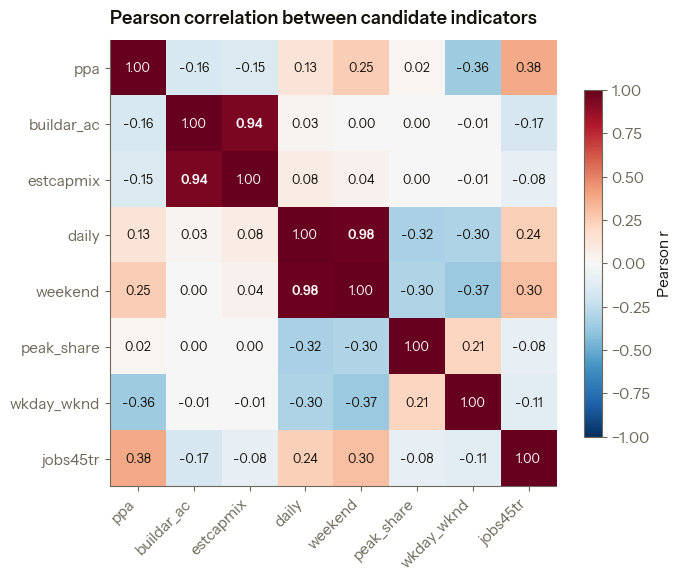

dropped as redundant: weekend (r=0.98 with daily), estcapmix (r=0.94 with buildar_ac)


In [8]:
CAND = ['ppa', 'buildar_ac', 'estcapmix', 'daily', 'weekend', 'peak_share', 'wkday_wknd', 'jobs45tr']
corr = site[CAND].corr()

fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CAND)), CAND, rotation=45, ha='right')
ax.set_yticks(range(len(CAND)), CAND)
for i in range(len(CAND)):
    for j in range(len(CAND)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 else INK,
                fontweight='bold' if i != j and abs(v) > 0.9 else 'normal')
ax.set_title('Pearson correlation between candidate indicators')
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.75, label='Pearson r')
save('04-correlation', dpi=460, source=SRC_BOTH)

print('dropped as redundant: weekend (r=%.2f with daily), estcapmix (r=%.2f with buildar_ac)'
      % (corr.loc['daily', 'weekend'], corr.loc['buildar_ac', 'estcapmix']))

## 05. Is the Green Line's problem its service?

Half the candidate sites sit on Green Line branches, and the branches have a
reputation for being slow. That is a testable claim, and three independent
measurements disagree with it.

The service data is one Saturday (3 February 2024), so it can describe how the
lines are built but not how reliable they are. Stop-to-stop time and station
dwell are structural; a single day is enough for those. Headway on a Saturday
is not a weekday headway and is labelled as such.

source: MBTA subway performance, 3 Feb 2024  ·  MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


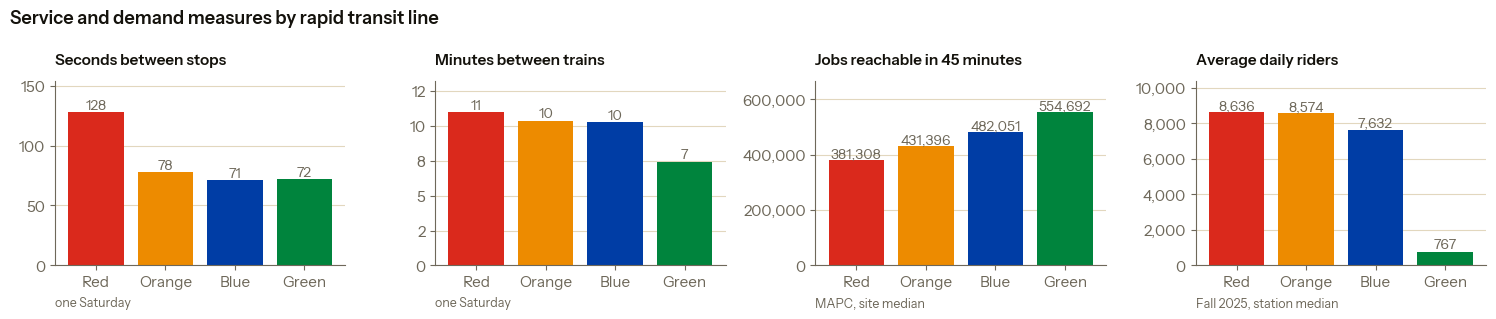

In [9]:
otp = pd.read_parquet(DATA + '2024-02-03-subway-on-time-performance-v1.parquet')
svc = otp.groupby('trunk_route_id').agg(
    sec_per_hop=('travel_time_seconds', 'median'),
    dwell=('dwell_time_seconds', 'median'),
    headway_min=('headway_trunk_seconds', lambda x: x.median() / 60)).drop('Mattapan', errors='ignore')

jobs = site.groupby('line').jobs45tr.median()
riders = station.groupby('line').daily.median().drop('Mattapan', errors='ignore')
panel_lines = ['Red', 'Orange', 'Blue', 'Green']

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
series = [(svc.sec_per_hop, 'Seconds between stops', 'one Saturday'),
          (svc.headway_min, 'Minutes between trains', 'one Saturday'),
          (jobs, 'Jobs reachable in 45 minutes', 'MAPC, site median'),
          (riders, 'Average daily riders', 'Fall 2025, station median')]
for ax, (ser, title, note) in zip(axes, series):
    v = ser.reindex(panel_lines).dropna()
    ax.bar(v.index, v.values, color=[LINE_COLOR[i] for i in v.index])
    for i, (k, val) in enumerate(v.items()):
        ax.text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=10, color=MUTE)
    ax.set_title(title, fontsize=11)
    ax.text(0.0, -0.22, note, transform=ax.transAxes, fontsize=9, color=MUTE)
    ax.set_ylim(0, v.max() * 1.2)
    # Full figures on the axis too. Dividing by a thousand and writing `(000s)`
    # in the title asks a reader to multiply before they can read the bar, and
    # the other panels in this strip print their numbers whole.
    ax.yaxis.set_major_formatter(thousands)
    ax.grid(axis='x', visible=False)
fig.suptitle('Service and demand measures by rapid transit line',
             x=0.005, ha='left', fontweight='bold', fontsize=13)
plt.tight_layout()
save('05-by-line', source=f'MBTA subway performance, 3 Feb 2024  ·  {SRC_MAPC}  ·  {SRC_RIDE}')

**The Green Line branches have the shortest hop times, the most frequent
service and the best regional job access of any line in the candidate set, and
roughly a tenth of the ridership.** What makes a Green Line trip slow is the
number of stops, not the speed between them — and whatever is holding those
sites back, it is not the service they get.

## 06. Six autumns, and why the vintage matters

Every number in the 2024 model came from Fall 2023. Adding Fall 2017, 2018,
2019, 2024 and 2025 turns a snapshot into a trajectory, and the trajectory says
the snapshot was taken at the bottom.

MBTA flags a track-circuit problem in the Fall 2018 file, so Fall 2019 is used
as the pre-pandemic baseline.

source: MBTA rail ridership, Fall 2017, 2018, 2019, 2023, 2024 and 2025


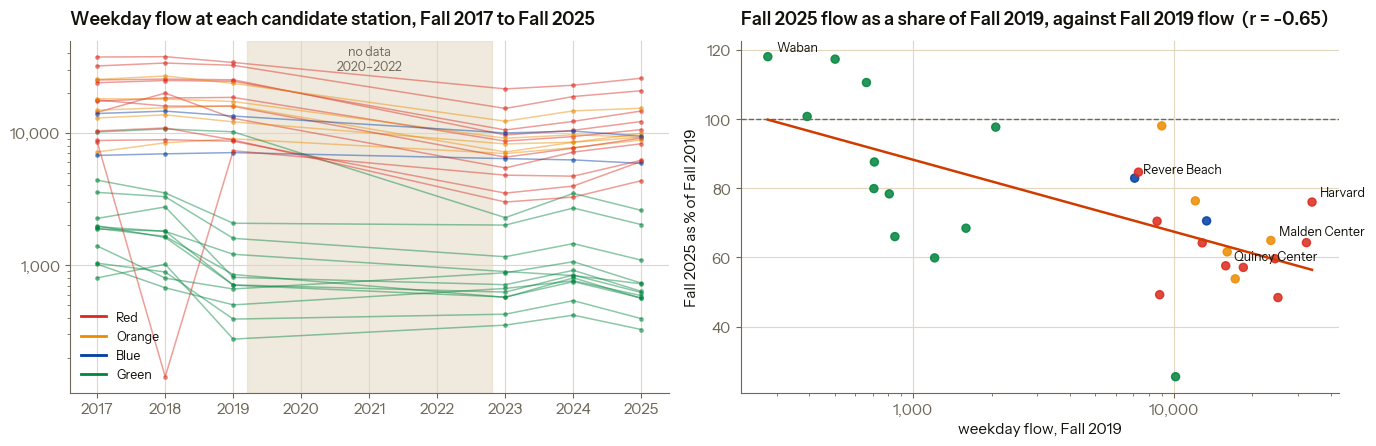

median flow change across candidate stations, Fall 2023 to Fall 2025: +12.3%


In [10]:
def season_panel():
    old = load_ridership('Rail_Ridership_by_Season_Time_Period_RouteLine_and_Stop.csv')
    f23 = load_ridership('Fall_2023_MBTA_Rail_Ridership_Data.csv')
    allr = pd.concat([old, f23, f24, f25], ignore_index=True)
    wd = allr[allr.day_type == 'weekday']
    p = wd.groupby(['stop_name', 'season']).flow.sum().unstack('season')
    return p[[c for c in ['Fall 2017', 'Fall 2018', 'Fall 2019', 'Fall 2023',
                          'Fall 2024', 'Fall 2025'] if c in p.columns]]


panel = season_panel()
cand_st = sorted(site.station.unique())
pc = panel.reindex(cand_st).dropna(subset=['Fall 2019', 'Fall 2025'])
pc = pc.assign(recovery=pc['Fall 2025'] / pc['Fall 2019'] * 100,
               line=[station.line.get(i) for i in pc.index])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))
years = [2017, 2018, 2019, 2023, 2024, 2025]
cols = [c for c in panel.columns]
for st_name, row in pc.iterrows():
    ax1.plot(years, [row[c] for c in cols], color=LINE_COLOR.get(row.line, MUTE),
             alpha=0.45, lw=1.1, marker='o', ms=2.5)
ax1.set_yscale('log')
ax1.set_title('Weekday flow at each candidate station, Fall 2017 to Fall 2025')
ax1.yaxis.set_major_formatter(thousands)
ax1.axvspan(2019.2, 2022.8, color=FAINT, alpha=0.5)
ax1.text(2021, ax1.get_ylim()[1] * 0.6, 'no data\n2020–2022', ha='center', color=MUTE, fontsize=9)
for ln, c in LINE_COLOR.items():
    if ln in pc.line.values:
        ax1.plot([], [], color=c, label=ln, lw=2)
ax1.legend(frameon=False, fontsize=9, loc='lower left')

ax2.scatter(pc['Fall 2019'], pc.recovery, s=34,
            c=[LINE_COLOR.get(l, MUTE) for l in pc.line], alpha=0.85)
ax2.set_xscale('log')
ax2.axhline(100, color=MUTE, lw=1, ls='--')
r = np.corrcoef(np.log(pc['Fall 2019']), pc.recovery)[0, 1]
z = np.polyfit(np.log(pc['Fall 2019']), pc.recovery, 1)
xs = np.linspace(np.log(pc['Fall 2019'].min()), np.log(pc['Fall 2019'].max()), 50)
ax2.plot(np.exp(xs), np.polyval(z, xs), color=ACCENT, lw=1.8)
ax2.set_title(f'Fall 2025 flow as a share of Fall 2019, against Fall 2019 flow  (r = {r:.2f})')
ax2.set_xlabel('weekday flow, Fall 2019')
ax2.set_ylabel('Fall 2025 as % of Fall 2019')
ax2.xaxis.set_major_formatter(thousands)
for nm in ['Quincy Center', 'Malden Center', 'Revere Beach', 'Harvard', 'Waban']:
    if nm in pc.index:
        ax2.annotate(nm, (pc.loc[nm, 'Fall 2019'], pc.loc[nm, 'recovery']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9, color=INK)
plt.tight_layout()
save('06-trend', source='MBTA rail ridership, Fall 2017, 2018, 2019, 2023, 2024 and 2025')

print('median flow change across candidate stations, Fall 2023 to Fall 2025: '
      f'{(pc["Fall 2025"] / pc["Fall 2023"]).median() * 100 - 100:+.1f}%')

Two conclusions, and one of them is a decision about the model.

**Fall 2023 was a trough.** Across the candidate stations, weekday flow is
materially higher in Fall 2025 than in Fall 2023. Measuring demand on the 2023
file understates it, so the model here uses Fall 2025.

**Recovery does not become an indicator.** It is tempting: growth sounds like
exactly what a site-selection model should reward. But percentage recovery is
an artefact of the base — Riverside recovered to 236% of 2019 while losing
1,251 riders a day since 2023 — and absolute growth correlates 0.87 with
ridership itself, which is the redundancy trap from Section 04. Six seasons of
data changed *which year the model measures*, not how many indicators it has.

## 07. The shortlist that needs no weights

A site is *dominated* if some other site beats it on all four indicators at
once. Nothing dominated can be the right answer under any weighting, so the
dominated sites can be removed before any judgement is applied. What is left is
the Pareto frontier.

This is the step the 2024 model had no equivalent of. It cuts the field by nine tenths
using only the data.

station codes: ALE Alewife, AMO Amory Street, ASM Assembly, BAB Babcock Street, BAL Ball Square, BRA Braintree, BRH Brookline Hills, BRV Brookline Village, CEN Central, CHE Chestnut Hill, COO Coolidge Corner, DAV Davis, EAS East Somerville, ELI Eliot, GIL Gilman Square, HAR Harvard, HAV Harvard Avenue, LEC Lechmere, MAG Magoun Square, MAL Malden Center, MED Medford/Tufts, NEC Newton Centre, NEH Newton Highlands, NOR North Quincy, OAK Oak Grove, POR Porter, QUA Quincy Adams, QUC Quincy Center, REV Revere Beach, SAI Saint Mary's Street, SUL Sullivan Square, SUM Summit Avenue, TAP Tappan Street, UNI Union Square, WAB Waban, WAS Washington Square, WEL Wellington, WOL Wollaston, WON Wonderland
251 sites, 22 on the frontier (9% kept, no weights used)


source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


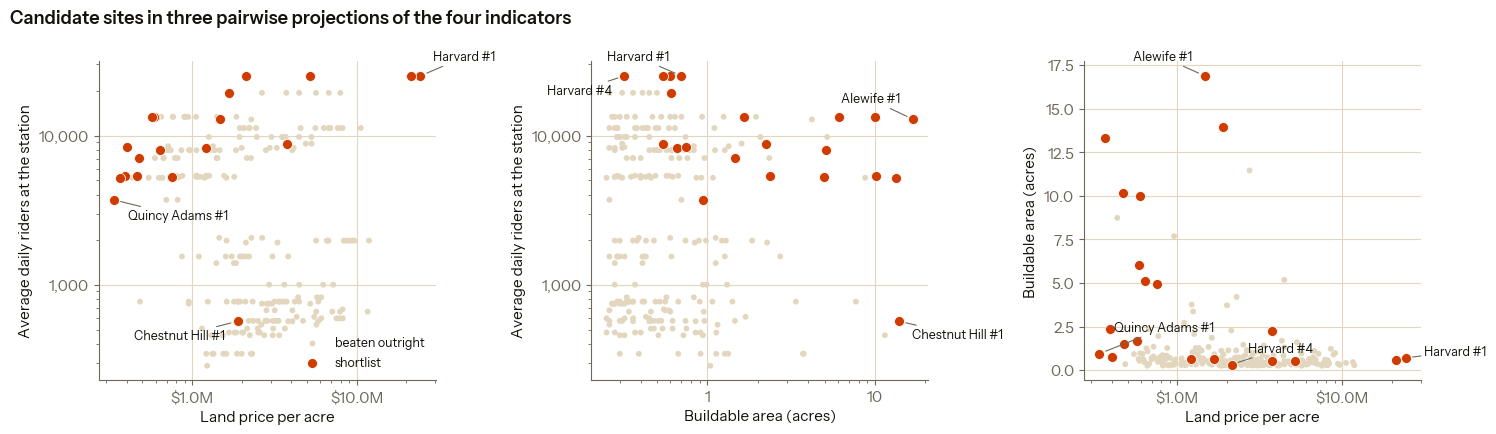

In [11]:
def pareto_mask(frame, cols, lower):
    A = frame[cols].to_numpy(float).copy()
    for i, c in enumerate(cols):
        if c in lower:
            A[:, i] = -A[:, i]
    keep = np.ones(len(A), bool)
    for i in range(len(A)):
        if keep[i] and (np.all(A >= A[i], axis=1) & np.any(A > A[i], axis=1)).any():
            keep[i] = False
    return keep


def name_ends(ax, frame, xcol, ycol, offsets=None):
    """Name the frontier site at each end of each axis: four labels, one rule.

    Labelling two of twenty-seven invites the question of why those two.
    Labelling all twenty-seven buries the shape the panel exists to show. The
    ends of the axes are a rule a caption can state in one clause, and they are
    the points a reader wants named anyway.
    """
    DEFAULT = {'xmin': (-9, -13), 'xmax': (9, 11), 'ymin': (9, -12), 'ymax': (-9, 11)}
    off = {**DEFAULT, **(offsets or {})}
    picks = {'xmin': frame[xcol].idxmin(), 'xmax': frame[xcol].idxmax(),
             'ymin': frame[ycol].idxmin(), 'ymax': frame[ycol].idxmax()}
    seen = set()
    for key, i in picks.items():
        if i in seen:
            continue
        seen.add(i)
        dx, dy = off[key]
        # The identifier, which is already the station and a number.
        ax.annotate(frame.sid[i], (frame[xcol][i], frame[ycol][i]),
                    textcoords='offset points', xytext=(dx, dy), fontsize=9,
                    color=INK, zorder=6, ha='left' if dx > 0 else 'right',
                    arrowprops=dict(arrowstyle='-', color=MUTE, lw=0.8,
                                    shrinkA=0, shrinkB=5))

site['pareto'] = pareto_mask(site, IND, LOWER_IS_BETTER)

# A parcel needs a name short enough for a chart axis and unique enough to carry
# from a table to a map. `Assembly, 2.3 ac` names two different parcels, so the
# acreage does not even do the second job, and `Malden Center` on its own names
# three.
#
# The station and a number for the parcel, largest first: `Malden Center #1` is
# the ten acres and `Malden Center #3` is the acre and a half two streets over.
#
# The map gets a short form of the same thing, three letters and the number,
# because two dozen markers cannot each carry a station name at the zoom the
# map opens at. The letters are the station's own, so the code is guessable
# rather than arbitrary, and they are all the same width, which is what lets
# them sit next to each other without the eye having to measure them.
STATION_CODE = {
    # Where the plain first three letters are unhelpful or shared. Both halves
    # of a pair are set by hand, so neither keeps the ambiguous form: BRO would
    # be as true of Brookline Village as of Brookline Hills.
    'Assembly': 'ASM',
    'Brookline Hills': 'BRH', 'Brookline Village': 'BRV',
    'Harvard Avenue': 'HAV',
    'Newton Centre': 'NEC', 'Newton Highlands': 'NEH',
    'Quincy Adams': 'QUA', 'Quincy Center': 'QUC',
}


def _code_options(name):
    """Three-letter codes for one station, best first."""
    words = name.replace('/', ' ').replace("'", '').split()
    flat = ''.join(words)
    out = [flat[:3]]
    if len(words) > 2:
        out.append(''.join(w[0] for w in words[:3]))
    if len(words) > 1:
        out += [words[0][:2] + words[1][0], words[0][0] + words[1][:2]]
    out += [flat[:2] + flat[3:4], flat[:1] + flat[2:4]]
    return [c.upper() for c in out if len(c) == 3]


_taken = {c for c in STATION_CODE.values()}
_codes = dict(STATION_CODE)
for _st in sorted(site.station.unique()):
    if _st in _codes:
        continue
    _codes[_st] = next(c for c in _code_options(_st) if c not in _taken)
    _taken.add(_codes[_st])
assert len(set(_codes.values())) == len(_codes)

# Two forms of the same identifier. `Malden Center #1` is what the charts, the
# tables and the write-up use, because it reads without a key. `MAL-1` is for
# the map alone, where a marker has room for five characters and two dozen of
# them have to sit side by side.
site['sid'] = ''
site['code'] = ''
for _st, _g in site.groupby('station'):
    _order = _g.sort_values('buildar_ac', ascending=False).index
    site.loc[_order, 'sid'] = [f'{_st} #{i}' for i in range(1, len(_order) + 1)]
    site.loc[_order, 'code'] = [f'{_codes[_st]}-{i}' for i in range(1, len(_order) + 1)]
assert site.sid.is_unique and site.code.is_unique
print('station codes:',
      ', '.join(f'{_codes[k]} {k}' for k in sorted(site.station.unique())))
print(f'{len(site)} sites, {site.pareto.sum()} on the frontier '
      f'({site.pareto.sum()/len(site):.0%} kept, no weights used)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
pairs = [('ppa', 'daily'), ('buildar_ac', 'daily'), ('ppa', 'buildar_ac')]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(site.loc[~site.pareto, x], site.loc[~site.pareto, y],
               s=18, color=FAINT, edgecolor='none', label='beaten outright')
    ax.scatter(site.loc[site.pareto, x], site.loc[site.pareto, y],
               s=52, color=ACCENT, edgecolor='white', lw=0.6, zorder=3, label='shortlist')
    ax.set_xlabel(NICE[x]); ax.set_ylabel(NICE[y])
    if x == 'ppa':
        ax.set_xscale('log'); ax.xaxis.set_major_formatter(FuncFormatter(money))
    if y == 'daily':
        ax.set_yscale('log'); ax.yaxis.set_major_formatter(thousands)
    if x == 'buildar_ac':
        ax.set_xscale('log')
        # Plain acres. The default log formatter prints 10^0 and 10^1, which
        # nobody reads as one acre and ten.
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
        ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())

F = site[site.pareto]
name_ends(axes[0], F, 'ppa', 'daily', {'xmin': (10, -14), 'ymin': (-9, -13)})
name_ends(axes[1], F, 'buildar_ac', 'daily', {'xmax': (-9, 12), 'ymin': (9, -12)})
name_ends(axes[2], F, 'ppa', 'buildar_ac', {'xmin': (11, 16), 'xmax': (13, 2),
                                            'ymin': (12, 9)})
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle('Candidate sites in three pairwise projections of the four indicators',
             x=0.005, ha='left', fontweight='bold', fontsize=13)
plt.tight_layout()
save('07-pareto', source=SRC_BOTH)

### What a fifth criterion would cost

Job access is a real quantity, it is not redundant with any of the four, and
one of the scenarios below leans on it. So why is it not a fifth indicator?

Because dominance gets weaker with every criterion added. Beating a parcel on
four measures at once is hard; on five it is harder, so fewer parcels are
beaten and more survive. The cell below runs the same filter with job access
added and reports what that does.

In [12]:
five_mask = pareto_mask(site, IND + ['jobs45tr'], LOWER_IS_BETTER)
gained = site[five_mask & ~site.pareto]
print(f'four indicators: {site.pareto.sum():>3} of {len(site)} survive'
      f'  ({site.pareto.sum() / len(site):.0%})')
print(f'five, with job access: {five_mask.sum():>3} of {len(site)}'
      f'  ({five_mask.sum() / len(site):.0%})')
print('none of the four-indicator shortlist drops out:',
      bool(not (site.pareto & ~five_mask).any()))
print(f'\nthe {len(gained)} the fifth criterion rescues, at the median:'
      f'  ${gained.ppa.median() / 1e6:.2f}M an acre,'
      f'  {gained.buildar_ac.median():.2f} ac,'
      f'  {gained.daily.median():,.0f} riders,'
      f'  {gained.jobs45tr.median():,.0f} jobs in 45 min')
print('against the 251 overall:'
      f'  ${site.ppa.median() / 1e6:.2f}M an acre,'
      f'  {site.buildar_ac.median():.2f} ac,'
      f'  {site.daily.median():,.0f} riders,'
      f'  {site.jobs45tr.median():,.0f} jobs')
print('where they are:', gained.municipal.value_counts().to_dict())

four indicators:  22 of 251 survive  (9%)
five, with job access:  54 of 251  (22%)
none of the four-indicator shortlist drops out: True

the 32 the fifth criterion rescues, at the median:  $1.88M an acre,  0.83 ac,  5,250 riders,  694,076 jobs in 45 min
against the 251 overall:  $2.20M an acre,  0.50 ac,  3,705 riders,  510,366 jobs
where they are: {'Somerville': 11, 'Cambridge': 8, 'Brookline': 5, 'Revere': 3, 'Malden': 2, 'Medford': 1, 'Quincy': 1, 'Braintree': 1}


**The rescued parcels survive on job access alone.** The 32 that the fifth
criterion adds sit at a median 694,000 jobs within 45 minutes against 510,000
for the candidate set, and on everything else they are ordinary: a shade
cheaper, a shade busier, a shade larger than the median parcel. That is the
whole mechanism. A criterion that ranks these parcels almost independently of
the others -- job access correlates minus 0.05 with the four combined --
hands every parcel that happens to score well on it one axis where nothing
beats it, and one axis is all dominance requires.

So job access stays out of the filter and out of the composite, and appears
where it can be argued with instead: as the measure one scenario weights
heavily, and as a column in the baseline test.

print(site[site.pareto].groupby('municipal').size().sort_values(ascending=False).to_string())

## 08. Three kinds of site

Twenty-four is still too many to describe one at a time, and they are not one
kind of thing. Standardising the four indicators and clustering gives groups
that can be named. The silhouette score keeps creeping up past three clusters,
but three is what can be described in words, and a typology nobody can name is
not a typology. The scores are printed below so the trade is visible rather
than asserted.

silhouette by k: {2: 0.312, 3: 0.348, 4: 0.379, 5: 0.379, 6: 0.392}

                                ppa  buildar_ac    daily  peak_share  sites  frontier
Small, expensive, quiet  2916666.67        0.46   745.43        0.53    113         0
Small, expensive, busy   1590117.70        0.52  8268.57        0.48    130        17
Big and cheap             775223.88       10.82  5210.71        0.49      8         5


source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


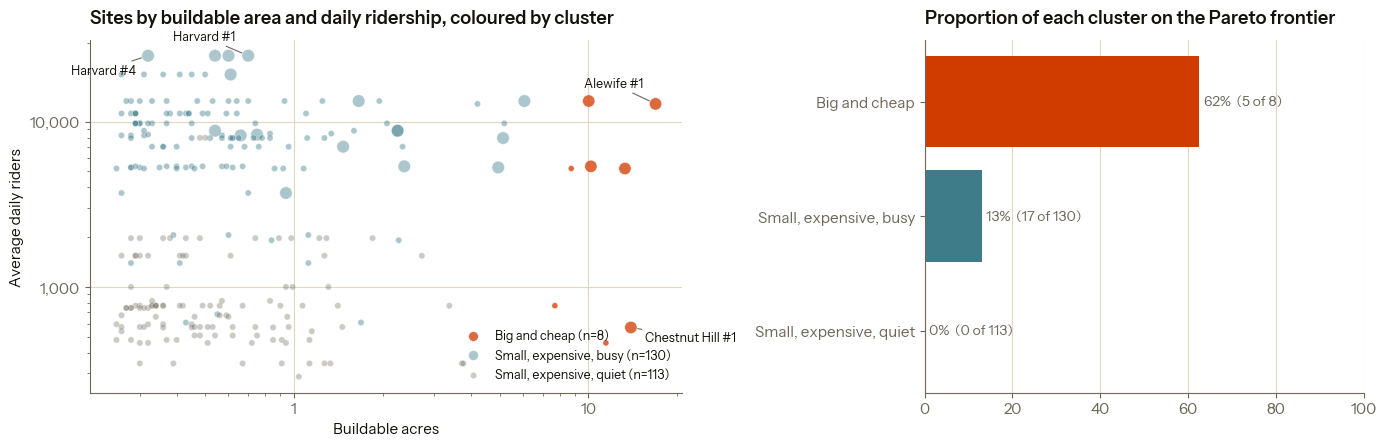


'Small, expensive, quiet' is 45% of the candidate pool and 0 of 22 frontier places.
It is mostly: Brookline (38), Somerville (37), Newton (28)


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Z = StandardScaler().fit_transform(site[IND])
sil = {k: silhouette_score(Z, KMeans(k, n_init=20, random_state=7).fit_predict(Z))
       for k in range(2, 7)}
print('silhouette by k:', {k: round(v, 3) for k, v in sil.items()})

site['cluster'] = KMeans(3, n_init=20, random_state=7).fit_predict(Z)
prof = site.groupby('cluster')[IND].median()
prof['sites'] = site.groupby('cluster').size()
prof['frontier'] = site.groupby('cluster').pareto.sum()
NAMES = {int(prof.buildar_ac.idxmax()): 'Big and cheap',
         int(prof.daily.idxmax()): 'Small, expensive, busy'}
for i in prof.index:
    NAMES.setdefault(int(i), 'Small, expensive, quiet')
site['type'] = site.cluster.map(NAMES)
prof.index = [NAMES[int(i)] for i in prof.index]
print()
print(prof.round(2).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6),
                               gridspec_kw={'width_ratios': [1.35, 1]})
TYPE_COLOR = {'Big and cheap': ACCENT, 'Small, expensive, busy': ACCENT2, 'Small, expensive, quiet': MUTE}
for t, g in site.groupby('type'):
    ax1.scatter(g.buildar_ac, g.daily, s=np.where(g.pareto, 80, 20),
                color=TYPE_COLOR[t], alpha=np.where(g.pareto, 1.0, 0.35).mean(),
                edgecolor='white', lw=0.5, label=f'{t} (n={len(g)})')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Buildable acres'); ax1.set_ylabel('Average daily riders')
ax1.yaxis.set_major_formatter(thousands)
ax1.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
ax1.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
name_ends(ax1, site[site.pareto], 'buildar_ac', 'daily',
          {'xmax': (-9, 12), 'ymin': (10, -10)})
ax1.legend(frameon=False, fontsize=9, loc='lower right')
ax1.set_title('Sites by buildable area and daily ridership, coloured by cluster')

share = (site.groupby('type').pareto.sum() / site.groupby('type').size() * 100).sort_values()
b = ax2.barh(share.index, share.values, color=[TYPE_COLOR[i] for i in share.index])
for bar, (k, v) in zip(b, share.items()):
    ax2.text(v + 1, bar.get_y() + bar.get_height() / 2,
             f'{v:.0f}%  ({site[site.type==k].pareto.sum()} of {(site.type==k).sum()})',
             va='center', fontsize=10, color=MUTE)
ax2.set_xlim(0, share.max() * 1.6)
ax2.set_title('Proportion of each cluster on the Pareto frontier')
ax2.grid(axis='y', visible=False)
plt.tight_layout()
save('08-typology', source=SRC_BOTH)

quiet = site[site.type == 'Small, expensive, quiet']
print(f"\n'Small, expensive, quiet' is {len(quiet)/len(site):.0%} of the candidate pool and "
      f"{quiet.pareto.sum()} of {site.pareto.sum()} frontier places.")
print('It is mostly:', ', '.join(f'{m} ({n})' for m, n in quiet.municipal.value_counts().head(3).items()))

## 09. Weights are a position, so let each position speak

I could not defend one set of weights in 2024 and I cannot now. The honest
response is not to pick harder, it is to stop pretending there is one answer.

Each scenario below is a position somebody could actually hold, written as a
weight vector. None of them is *the* answer. The spread between them is the
result.

Scores are percentiles against all 3,028 regional MAPC sites, not min-max
inside the shortlist, so a site's score does not move when the shortlist does.

In [14]:
REGION = s[s.ppa > 0]
REF = {'ppa': REGION.ppa, 'buildar_ac': s.buildar_ac.dropna(), 'jobs45tr': s.jobs45tr.dropna()}

def percentile(col):
    base = REF.get(col, site[col]).to_numpy()
    p = site[col].apply(lambda v: (base < v).mean() * 100)
    return 100 - p if col in LOWER_IS_BETTER else p

# The four indicators, plus job access, which no scenario weights: it is kept
# as a percentile so the appendix can score a job-access-first stance without
# rebuilding the frame.
PCT = pd.DataFrame({c: percentile(c) for c in IND + ['jobs45tr']}, index=site.index)

SCENARIOS = {
    'Developer (cost first)': ({'ppa': .50, 'buildar_ac': .25, 'daily': .15, 'peak_share': .10},
                              'Land is paid before anything earns. Minimise it.'),
    'City (housing first)':   ({'buildar_ac': .50, 'ppa': .20, 'daily': .20, 'peak_share': .10},
                              'The zoning law exists to produce homes. Maximise how many fit.'),
    'Transit agency (ridership first)':        ({'daily': .40, 'peak_share': .30, 'ppa': .15, 'buildar_ac': .15},
                              'Put density where the trains already run.'),
    'Place-making (all-day use first)':         ({'peak_share': .40, 'buildar_ac': .25, 'daily': .20, 'ppa': .15},
                              'Shops need customers at noon, not only at eight.'),
    'No prior (all four equal)':       ({'ppa': .25, 'buildar_ac': .25, 'daily': .25, 'peak_share': .25},
                              'I cannot tell these four apart, so I will not pretend to.'),
}

scores = pd.DataFrame({k: sum(PCT[c] * w for c, w in v[0].items())
                       for k, v in SCENARIOS.items()}, index=site.index)
# The identifier already carries the station, so it is the whole label: short
# enough for a chart axis, readable without a legend, unique across all 251.
label = site.sid

rows = []
for k in SCENARIOS:
    for rank, i in enumerate(scores[k].nlargest(5).index, 1):
        rows.append(dict(scenario=k, rank=rank, site=label[i], line=site.line[i],
                         acres=round(site.buildar_ac[i], 1), ppa=round(site.ppa[i]),
                         daily=round(site.daily[i]), score=round(scores[k][i], 1),
                         frontier=bool(site.pareto[i])))
top5 = pd.DataFrame(rows)
winners = top5[top5['rank'] == 1].set_index('scenario')
print(winners[['site', 'line', 'acres', 'ppa', 'daily', 'score', 'frontier']].to_string())
print('\nevery scenario winner is on the frontier:', bool(winners.frontier.all()))

                                              site    line  acres     ppa  daily  score  frontier
scenario                                                                                         
Developer (cost first)                Braintree #1     Red   13.3  363718   5211   76.4      True
City (housing first)              Malden Center #1  Orange   10.0  595818  13356   82.3      True
Transit agency (ridership first)  Malden Center #1  Orange   10.0  595818  13356   78.9      True
Place-making (all-day use first)   Revere Beach #1    Blue    4.9  753121   5289   78.9      True
No prior (all four equal)         Malden Center #1  Orange   10.0  595818  13356   76.3      True

every scenario winner is on the frontier: True


source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


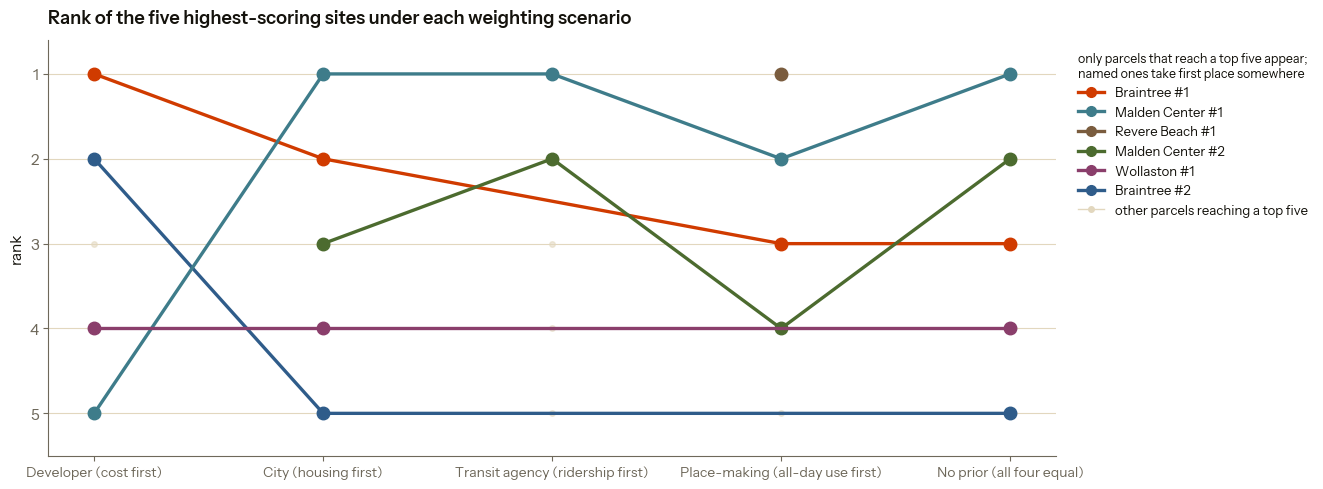

In [15]:
order = list(SCENARIOS)
shown = top5[top5['rank'] <= 5].copy()

# Every site that takes first place somewhere gets a colour, and the most
# persistent runners-up fill what is left of the palette. Choosing by frequency
# alone hid a site that wins one scenario and appears in few others, which is
# the case this chart exists to show.
champions = list(dict.fromkeys(winners.site))
others = [n for n in shown.site.value_counts().index if n not in champions]
PALETTE = [ACCENT, ACCENT2, '#7A5C3E', '#4C6B2F', '#8A3E6B', '#2F5C8A']
highlight = dict(zip((champions + others)[:len(PALETTE)], PALETTE))

fig, ax = plt.subplots(figsize=(13, 5.4))
for nm, g in shown.groupby('site'):
    g = g.sort_values('scenario', key=lambda c: c.map(order.index))
    xs = [order.index(sc) for sc in g.scenario]
    hot = nm in highlight
    ax.plot(xs, g['rank'].values, '-o', color=highlight.get(nm, FAINT),
            lw=2.4 if hot else 1, ms=9 if hot else 4,
            zorder=3 if hot else 1, alpha=1 if hot else 0.55)

# Names go in a column beside the plot. Six labels on a six-column chart collide
# wherever they are placed on the lines themselves.
handles = [plt.Line2D([], [], color=c, lw=2.4, marker='o', ms=7, label=n)
           for n, c in highlight.items()]
handles.append(plt.Line2D([], [], color=FAINT, lw=1, marker='o', ms=4,
                          label='other parcels reaching a top five'))
ax.legend(handles=handles, frameon=False, fontsize=9.5, loc='upper left',
          bbox_to_anchor=(1.01, 1.0), alignment='left',
          title='only parcels that reach a top five appear;\nnamed ones take first place somewhere',
          title_fontsize=9)
ax.set_xticks(range(len(order)), [o.replace(', ', ',\n') for o in order], fontsize=10)
ax.set_yticks(range(1, 6))
ax.set_ylim(5.5, 0.6)
ax.set_ylabel('rank')
ax.set_title('Rank of the five highest-scoring sites under each weighting scenario')
ax.grid(axis='x', visible=False)
save('09-scenarios', source=SRC_BOTH)

## 10. How far does a position have to move before the answer does?

The scenarios are six points. Drawing weights at random fills in everything
between them and says how much of that space each site owns.

source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


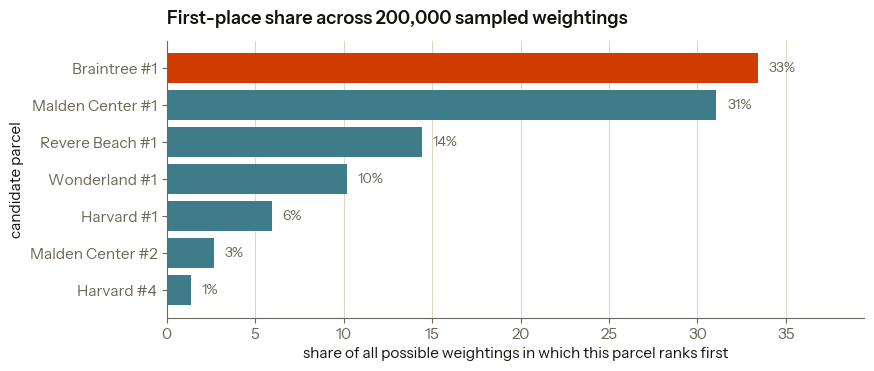

sid
Braintree #1        0.334
Malden Center #1    0.311
Revere Beach #1     0.144
Wonderland #1       0.102
Harvard #1          0.059
Malden Center #2    0.026
Harvard #4          0.014


In [16]:
rng = np.random.default_rng(7)
F = site[site.pareto]
PF = PCT.loc[F.index, IND].to_numpy()
draws = rng.dirichlet(np.ones(len(IND)), 200_000)
wins = np.bincount(np.argmax(draws @ PF.T, axis=1), minlength=len(F)) / len(draws)
share = pd.Series(wins, index=label[F.index]).sort_values(ascending=False)
share = share[share > 0.005]

fig, ax = plt.subplots(figsize=(9, 3.6))
b = ax.barh(share.index[::-1], share.values[::-1] * 100,
            color=[ACCENT if v == share.max() else ACCENT2 for v in share.values[::-1]])
for bar, v in zip(b, share.values[::-1]):
    ax.text(v * 100 + 0.6, bar.get_y() + bar.get_height() / 2, f'{v:.0%}', va='center',
            fontsize=10, color=MUTE)
ax.set_xlabel('share of all possible weightings in which this parcel ranks first')
ax.set_ylabel('candidate parcel')
ax.set_title('First-place share across 200,000 sampled weightings')
ax.set_xlim(0, share.max() * 118)
ax.grid(axis='y', visible=False)
save('10-weight-space', source=SRC_BOTH)
print(share.round(3).to_string())

## 11. Does the composite beat sorting on one column?

If a weighted combination of four indicators ranks sites the same way as one of
them alone, the combination is decoration. This is the cheapest check available
and the easiest to skip.

source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


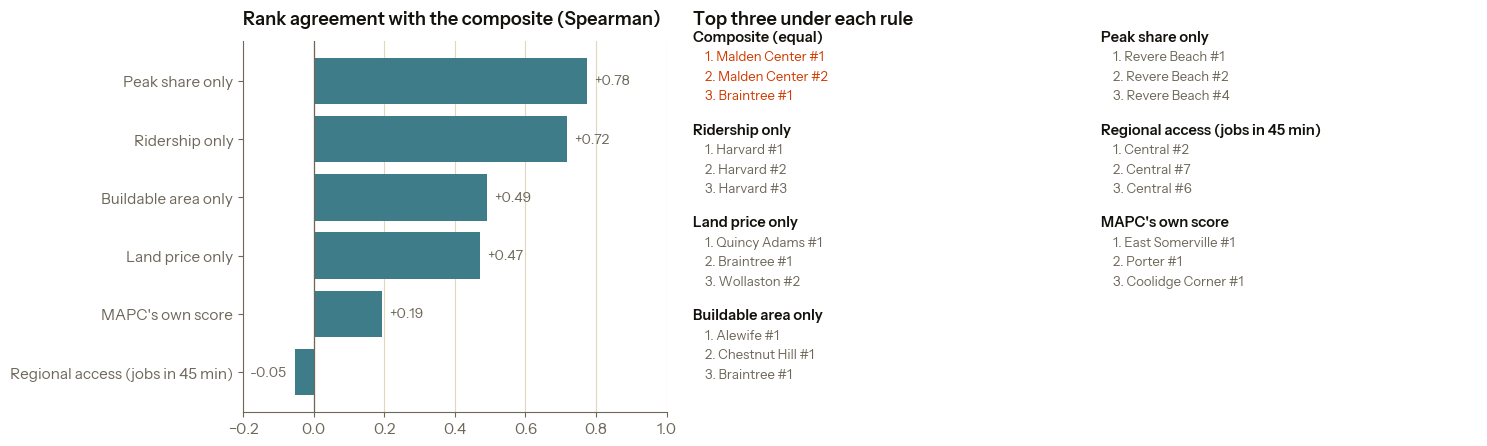

  top of "Composite (equal)": Malden Center #1
  top of "Ridership only": 4 parcels tied at Harvard
  top of "Land price only": Quincy Adams #1
  top of "Buildable area only": Alewife #1
  top of "Peak share only": 7 parcels tied at Revere Beach
  top of "Regional access (jobs in 45 min)": Central #2
  top of "MAPC's own score": East Somerville #1, Porter #1
No single indicator reproduces the composite top three.
Sorting on ridership alone gives the region's busiest square;
sorting on land price alone gives the park-and-ride with the least demand.
a regional-access-first weighting picks: Malden Center #1 | top three: Malden Center #1, Malden Center #2, Malden Center #4


In [17]:
BASE = {
    'Composite (equal)': scores['No prior (all four equal)'],
    'Ridership only': site.daily,
    'Land price only': -site.ppa,
    'Buildable area only': site.buildar_ac,
    'Peak share only': -site.peak_share,
    # Job access is not one of the four the shortlist was built on, but the
    # regional-access scenario weights it heavily, so leaving it out of the
    # baseline test would exempt the one indicator the scenarios reach for.
    # Named for what it is a proxy for, with the measure stated: the other
    # columns are their own measure, this one stands in for a concept.
    'Regional access (jobs in 45 min)': site.jobs45tr,
    "MAPC's own score": site.regipctile,
}
ranks = pd.DataFrame({k: v.rank(ascending=False) for k, v in BASE.items()})
agree = ranks.corr(method='spearman')['Composite (equal)'].drop('Composite (equal)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6),
                               gridspec_kw={'width_ratios': [1, 1.85]})
a = agree.sort_values()
bars = ax1.barh(a.index, a.values, color=ACCENT2)
for bar, v in zip(bars, a.values):
    # Label outside the bar on whichever side the bar points. Job access comes
    # out slightly negative, and a label offset rightwards from it lands on the
    # axis.
    ax1.text(v + (0.02 if v >= 0 else -0.02), bar.get_y() + bar.get_height() / 2,
             f'{v:+.2f}', va='center', ha='left' if v >= 0 else 'right',
             fontsize=10, color=MUTE)
ax1.axvline(0, color=MUTE, lw=0.9)
ax1.set_xlim(min(-0.2, a.min() - 0.1), 1)
ax1.set_title('Rank agreement with the composite (Spearman)')
ax1.grid(axis='y', visible=False)

tops = {k: [label[i] for i in v.nlargest(3).index] for k, v in BASE.items()}
ax2.axis('off')
# Two columns, filled down. The row count follows the number of rules rather
# than a hardcoded three, so adding a rule reflows the panel instead of
# indexing off the end of it.
COL_X = (0.0, 0.52)
PER_COL = -(-len(tops) // len(COL_X))
ROW_STEP = 1.0 / PER_COL
LINE = ROW_STEP * 0.21
for n, (k, names) in enumerate(tops.items()):
    x = COL_X[n // PER_COL]
    y = 1.0 - (n % PER_COL) * ROW_STEP
    ax2.text(x, y, k, fontweight='bold', fontsize=10.5, transform=ax2.transAxes)
    for j, nm in enumerate(names):
        ax2.text(x + 0.015, y - LINE * (j + 1), f'{j+1}. {nm}', fontsize=9.5,
                 color=ACCENT if k.startswith('Composite') else MUTE, transform=ax2.transAxes)
ax2.set_title('Top three under each rule')
plt.tight_layout()
save('11-baselines', source=SRC_BOTH)

# Two of these columns are measured at the station, so every parcel beside the
# busiest station holds the same value and `nlargest(1)` would report an index
# order as a result. Four parcels tie on ridership and seven on peak share;
# those rules rank stations, and the page says so rather than picking one parcel
# out of the tie. MAPC's percentile saturates and ties two parcels at 100.0.
TIE_LIMIT = 2
_tops = []
for _k, _v in BASE.items():
    _t = list(_v[_v == _v.max()].index)
    print(f'  top of "{_k}":',
          ', '.join(label[i] for i in _t) if len(_t) <= TIE_LIMIT
          else f'{len(_t)} parcels tied at {site.station[_t[0]]}')
    if len(_t) <= TIE_LIMIT:
        _tops += _t
site['cited'] = site.index.isin(_tops)

print('No single indicator reproduces the composite top three.')
print('Sorting on ridership alone gives the region\'s busiest square;')
print('sorting on land price alone gives the park-and-ride with the least demand.')

# The other way a fifth measure could have entered: as a stance rather than
# as a criterion. Weighting job access at 0.40 and the three
# parcel-and-station measures at 0.20 each is a coherent position, and where
# it lands is the reason the scenario table can do without it.
JOB_FIRST = {'jobs45tr': .40, 'daily': .20, 'ppa': .20, 'buildar_ac': .20}
job_score = sum(PCT[c] * w for c, w in JOB_FIRST.items())
print('a regional-access-first weighting picks:', label[job_score.idxmax()],
      '| top three:', ', '.join(label[i] for i in job_score.nlargest(3).index))

## 12. An outside opinion, and why it differs

MAPC scores every site in its inventory for redevelopment potential on its own
criteria — health, travel choice, growth potential — which overlap with these
four but are not the same. That makes their percentile a useful outside check:
not a ground truth, but a second reading.

The two readings agree on direction and disagree on plenty of individual
parcels, and the disagreement is not noise. Their score is built out of things
this model does not weigh and leaves out two that it does, so the second panel
below is worth more than the correlation coefficient.

source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025


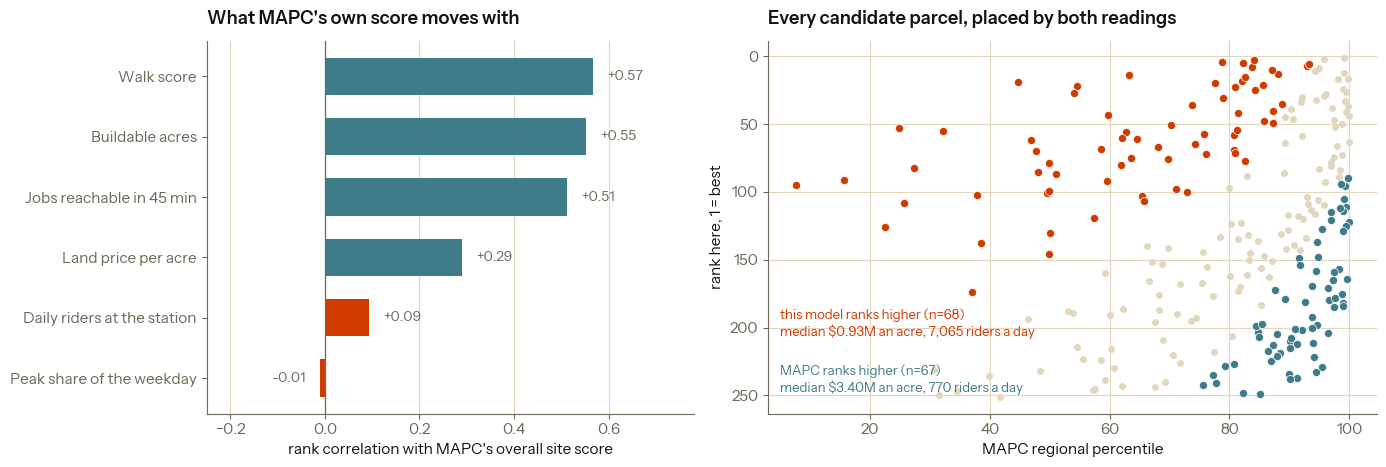

frontier median MAPC percentile 94 against 83 for the rest
Peak share of the weekday     -0.01
Daily riders at the station    0.09
Land price per acre            0.29
Jobs reachable in 45 min       0.51
Buildable acres                0.55
Walk score                     0.57

parcels more than 60 places apart:
  this model ranks higher  n= 68  $   929,172/ac   0.54 ac    7,065 riders  mostly Quincy (30 of 68)
  MAPC ranks higher        n= 67  $ 3,400,952/ac   0.52 ac      770 riders  mostly Brookline (29 of 67)
frontier median MAPC percentile 94 against 83 for the rest


In [18]:
v = site.dropna(subset=['regipctile']).copy()
v['ours'] = ranks.loc[v.index, 'Composite (equal)']
v['theirs'] = v.regipctile.rank(ascending=False)
v['gap'] = v.theirs - v.ours

# Left: what their overall score actually moves with. Spearman rather than
# Pearson, because the score is a percentile and the indicators are not.
WITH = [('walkscore', 'Walk score'), ('buildar_ac', 'Buildable acres'),
        ('jobs45tr', 'Jobs reachable in 45 min'), ('ppa', 'Land price per acre'),
        ('daily', 'Daily riders at the station'), ('peak_share', 'Peak share of the weekday')]
rho_with = pd.Series({lab: v.ovscr.corr(v[c], method='spearman') for c, lab in WITH})
rho_with = rho_with.sort_values()

# Right: the parcels the two readings place more than sixty positions apart.
CUT = 60
ours_up, theirs_up = v[v.gap > CUT], v[v.gap < -CUT]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8),
                               gridspec_kw={'width_ratios': [1, 1.25]})

bars = ax1.barh(rho_with.index, rho_with.values,
                color=[ACCENT if abs(x) < 0.15 else ACCENT2 for x in rho_with.values],
                height=0.62)
for b, x in zip(bars, rho_with.values):
    ax1.text(x + (0.03 if x >= 0 else -0.03), b.get_y() + b.get_height() / 2,
             f'{x:+.2f}', va='center', ha='left' if x >= 0 else 'right',
             fontsize=10, color=MUTE)
ax1.axvline(0, color=MUTE, lw=0.9)
ax1.set_xlim(-0.25, 0.78)
ax1.set_xlabel("rank correlation with MAPC's overall site score")
ax1.set_title("What MAPC's own score moves with")
ax1.grid(axis='y', visible=False)

ax2.scatter(v.regipctile, v.ours, s=16, color=FAINT, zorder=1)
ax2.scatter(ours_up.regipctile, ours_up.ours, s=34, color=ACCENT,
            edgecolor='white', lw=0.5, zorder=3)
ax2.scatter(theirs_up.regipctile, theirs_up.ours, s=34, color=ACCENT2,
            edgecolor='white', lw=0.5, zorder=3)
ax2.invert_yaxis()
ax2.set_xlabel('MAPC regional percentile')
ax2.set_ylabel('rank here, 1 = best')
ax2.set_title('Every candidate parcel, placed by both readings')

# The key and the figures in one block, in the empty bottom-left corner. A
# separate legend would say the group names twice and land on the points.
for grp, c, name, y in [(ours_up, ACCENT, 'this model ranks higher', 0.20),
                        (theirs_up, ACCENT2, 'MAPC ranks higher', 0.05)]:
    ax2.text(0.02, y, f'{name} (n={len(grp)})\n'
                      f'median ${grp.ppa.median()/1e6:.2f}M an acre, '
                      f'{grp.daily.median():,.0f} riders a day',
             transform=ax2.transAxes, fontsize=9.5, color=c, va='bottom')
plt.tight_layout()
save('12-validation', source=SRC_BOTH)

print(f'frontier median MAPC percentile {v.loc[v.pareto, "regipctile"].median():.0f}'
      f' against {v.loc[~v.pareto, "regipctile"].median():.0f} for the rest')
print(rho_with.round(2).to_string())
print(f'\nparcels more than {CUT} places apart:')
for name, grp in [('this model ranks higher', ours_up), ('MAPC ranks higher', theirs_up)]:
    print(f'  {name:<24} n={len(grp):>3}  ${grp.ppa.median():>10,.0f}/ac'
          f'  {grp.buildar_ac.median():>5.2f} ac  {grp.daily.median():>7,.0f} riders'
          f'  mostly {grp.municipal.value_counts().idxmax()}'
          f' ({grp.municipal.value_counts().max()} of {len(grp)})')

print(f"frontier median MAPC percentile {v[v.pareto].regipctile.median():.0f} "
      f"against {v[~v.pareto].regipctile.median():.0f} for the rest")

## 13. What the choice actually changes

The 2024 model gave land price the heaviest weight of the five, 30%. This runs
its cost model over each scenario winner to see how much that choice moves the
number it was supposed to protect.

            site                         scenario    ppa  buildable       land        total  land_pct  capacity_sqft
    Braintree #1           Developer (cost first) 363718       13.3 1391636.06 480891636.06      0.29      1738044.0
Malden Center #1             City (housing first) 595818       10.0 2279683.20 481779683.20      0.47      1306800.0
 Revere Beach #1 Place-making (all-day use first) 753121        4.9 2881546.53 482381546.53      0.60       640332.0

land spread across the winners: 2.1x
total cost spread across the winners: $1,489,910 (0.31%)
capacity spread: 2.7x
source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  construction and soft costs from the 2024 model


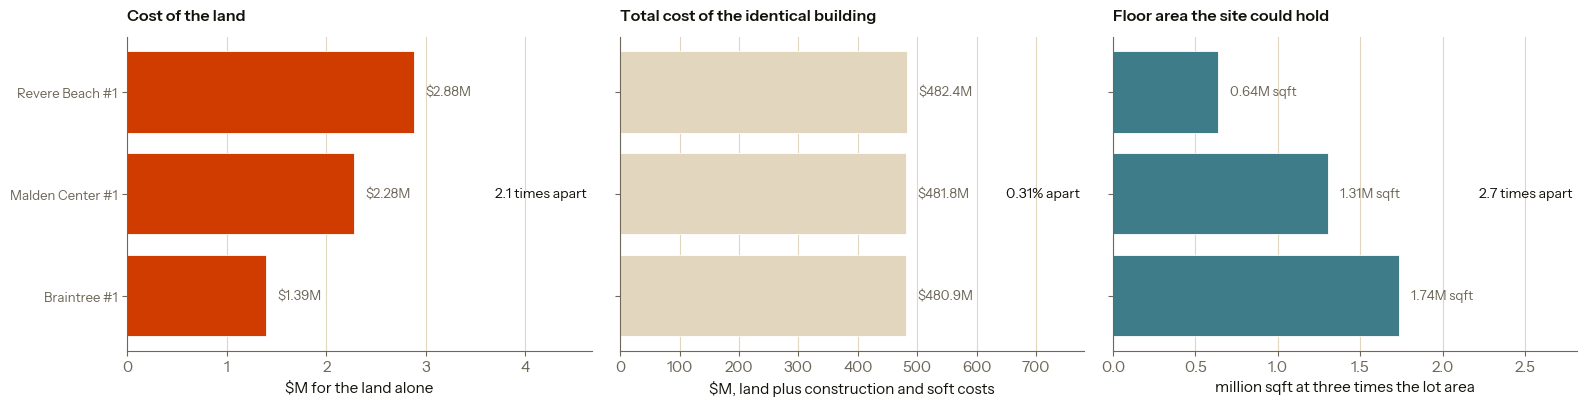

In [19]:
SQFT, FAR, BUILD_COST, SOFT = 500_000, 3, 700, 129_500_000
acres_needed = SQFT / FAR / 43_560

picks = winners.reset_index().drop_duplicates('site')
cost = pd.DataFrame({'site': picks.site.values,
                     'scenario': picks.scenario.values,
                     'ppa': picks.ppa.values,
                     'buildable': picks.acres.values})
cost['land'] = cost.ppa * acres_needed
cost['total'] = SQFT * BUILD_COST + cost.land + SOFT
cost['land_pct'] = cost.land / cost.total * 100
cost['capacity_sqft'] = cost.buildable * 43_560 * FAR
print(cost.round(2).to_string(index=False))
print(f"\nland spread across the winners: {cost.land.max() / cost.land.min():.1f}x")
print(f"total cost spread across the winners: "
      f"${cost.total.max()-cost.total.min():,.0f} ({cost.total.max()/cost.total.min()-1:.2%})")
print(f"capacity spread: {cost.capacity_sqft.max()/cost.capacity_sqft.min():.1f}x")

# Three panels, each on its own scale, because the three quantities differ by
# three orders of magnitude and a stacked bar buried the first of them: land
# drawn to the same axis as the total is a sliver half a per cent wide, which
# is the finding but is not a readable mark. Separated, the land panel shows
# what the stack hid — the land itself is twice as dear at one site as at
# another — and the totals beside it show how little of that survives.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
y = np.arange(len(cost))

PANELS = [
    (cost.land / 1e6, ACCENT, 'Cost of the land',
     '$M for the land alone',
     [f'${v/1e6:.2f}M' for v in cost.land],
     f'{cost.land.max() / cost.land.min():.1f} times apart'),
    (cost.total / 1e6, FAINT, 'Total cost of the identical building',
     '$M, land plus construction and soft costs',
     [f'${v/1e6:.1f}M' for v in cost.total],
     f'{cost.total.max() / cost.total.min() - 1:.2%} apart'),
    (cost.capacity_sqft / 1e6, ACCENT2, 'Floor area the site could hold',
     'million sqft at three times the lot area',
     [f'{v/1e6:.2f}M sqft' for v in cost.capacity_sqft],
     f'{cost.capacity_sqft.max() / cost.capacity_sqft.min():.1f} times apart'),
]
for ax, (ser, colour, title, xlab, marks, spread) in zip(axes, PANELS):
    ax.barh(y, ser, color=colour, edgecolor='white', lw=0.6)
    for i, (v, mark) in enumerate(zip(ser, marks)):
        ax.text(v + ser.max() * 0.04, i, mark, va='center', fontsize=9.5, color=MUTE)
    ax.set_xlim(0, ser.max() * 1.62)
    ax.set_title(title, fontsize=11.5)
    ax.set_xlabel(xlab)
    # The comparison the panel exists to support, in the empty right-hand
    # quarter that the value labels never reach.
    ax.text(0.99, 0.5, spread, transform=ax.transAxes, ha='right', va='center',
            fontsize=10, color=INK)
    ax.grid(axis='y', visible=False)
axes[0].set_yticks(y, cost.site, fontsize=9.5)
plt.tight_layout()
save('13-cost-vs-capacity', source=f'{SRC_MAPC}  ·  construction and soft costs from the 2024 model')

## 14. Where the 2024 answer ended up

The point of a second pass is not to be right where the first was wrong. It is
to see what the first pass could not see.

Quincy Center: 14 candidate sites, 1 on the frontier
best of them ranks 6 of 251 under equal weights
it wins 0 of the 5 scenarios

            frontier_sites  v1_rank
municipal                          
Quincy                   5      1.0
Cambridge                6      2.0
Newton                   1      3.0
Somerville               4      4.0
Revere                   2      5.0
Malden                   3      6.0
Braintree                1      7.0
Brookline                0      8.0
Medford                  0      NaN
source: MAPC Rethinking the Retail Strip Sites, Jan 2022  ·  MBTA rail ridership, Fall 2025  ·  2024 community ranking from the original notebook


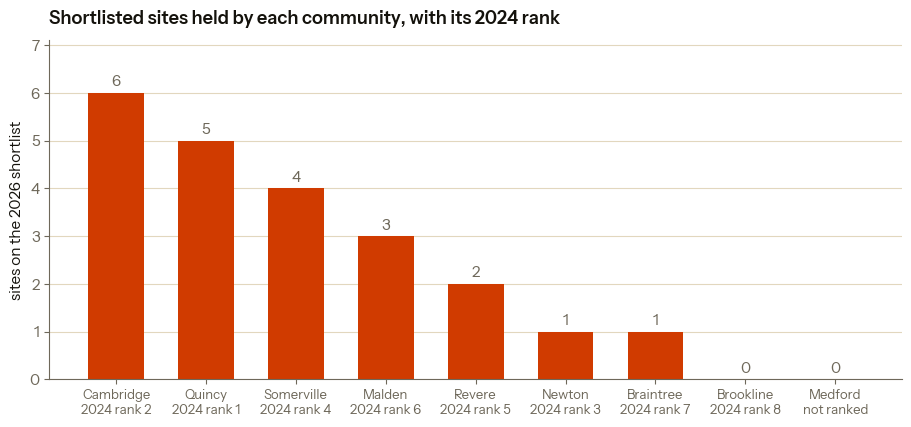

In [20]:
qc = site[site.station == 'Quincy Center']
qc_best = qc.nlargest(1, 'buildar_ac')
eq = scores['No prior (all four equal)']
print(f'Quincy Center: {len(qc)} candidate sites, {qc.pareto.sum()} on the frontier')
print(f'best of them ranks {int(eq.rank(ascending=False)[qc_best.index[0]])} of {len(site)} under equal weights')
print(f'it wins {sum(1 for k in SCENARIOS if label[scores[k].idxmax()].startswith("Quincy / Quincy Center"))} of the {len(SCENARIOS)} scenarios')

v1_rank = {'Quincy': 1, 'Cambridge': 2, 'Newton': 3, 'Somerville': 4,
           'Revere': 5, 'Malden': 6, 'Braintree': 7, 'Brookline': 8}
cmp = pd.DataFrame({'frontier_sites': site[site.pareto].groupby('municipal').size()})
cmp = cmp.reindex(sorted(set(site.municipal))).fillna(0).astype(int)
cmp['v1_rank'] = [v1_rank.get(m, np.nan) for m in cmp.index]
cmp = cmp.sort_values('v1_rank', na_position='last')
print()
print(cmp.to_string())

# Sorted by the bar, not by the 2024 rank. Ordering by the rank made a chart
# whose bars had no shape; ordering by the count gives it one, and the 2024
# rank under each name is then the thing that jumps around, which is the
# comparison the chart is for.
order = cmp.sort_values(['frontier_sites', 'v1_rank'],
                        ascending=[False, True], na_position='last')
ticks = [f'{m}\n{"not ranked" if np.isnan(r.v1_rank) else f"2024 rank {int(r.v1_rank)}"}'
         for m, r in order.iterrows()]

fig, ax = plt.subplots(figsize=(11, 4.4))
bars = ax.bar(range(len(order)), order.frontier_sites,
              color=[MUTE if np.isnan(r.v1_rank) else ACCENT for _, r in order.iterrows()],
              width=0.62)
for i, v in enumerate(order.frontier_sites):
    ax.text(i, v + 0.14, str(int(v)), ha='center', fontsize=11, color=MUTE)
ax.set_xticks(range(len(order)), ticks, fontsize=9.5)
ax.set_ylabel('sites on the 2026 shortlist')
ax.set_ylim(0, order.frontier_sites.max() + 1.1)
ax.set_title('Shortlisted sites held by each community, with its 2024 rank')
ax.grid(axis='x', visible=False)
save('14-then-and-now', source=f'{SRC_BOTH}  ·  2024 community ranking from the original notebook')

**The 2024 model discarded seven of eight communities before it looked at a
single station.** Its own write-up admitted that a strong station in a
mid-ranked community would never be evaluated. That is what happened: Malden
finished sixth and holds the site that wins three of five scenarios here.
Brookline finished eighth, was discarded first, and holds none of the frontier
either way. Medford was lost in the postcode join and never entered the model
at all.

Quincy Center is not a bad answer. It is still on the frontier. It was a narrow
answer, produced by a method that could not have found the alternatives.

### The two workflows

Drawn in this script rather than in a vector editor so the counts in it are
the ones the analysis produces. A methods diagram: it reports what each
workflow does at each stage and leaves the comparison to the caption.

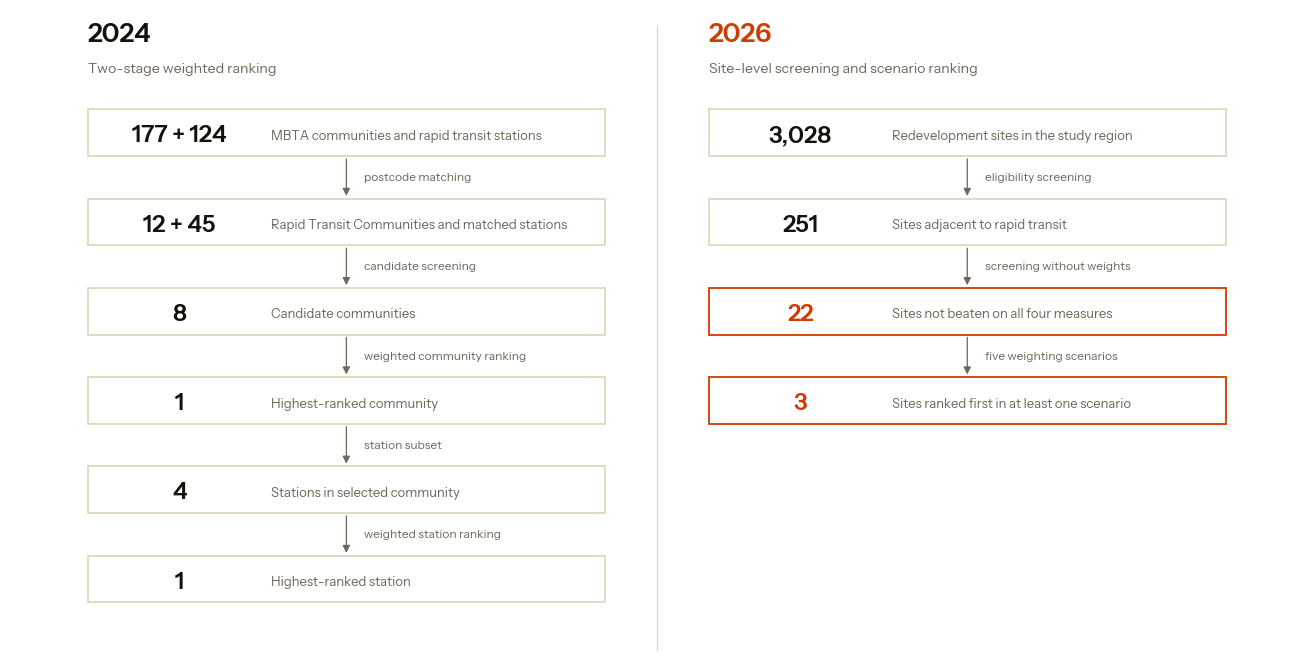

In [21]:
from matplotlib.patches import Rectangle, FancyArrowPatch

BOLD_F = mpl.font_manager.FontProperties(fname='fonts/InstrumentSans-SemiBold.ttf') \
    if os.path.exists('fonts/InstrumentSans-SemiBold.ttf') else None

n_sites, n_front, n_win = len(site), int(site.pareto.sum()), len(set(winners.site))

# (number, noun phrase, label on the arrow leading into this box)
LEFT = [('177 + 124', 'MBTA communities and rapid transit stations', None),
        ('12 + 45', 'Rapid Transit Communities and matched stations', 'postcode matching'),
        ('8', 'Candidate communities', 'candidate screening'),
        ('1', 'Highest-ranked community', 'weighted community ranking'),
        ('4', 'Stations in selected community', 'station subset'),
        ('1', 'Highest-ranked station', 'weighted station ranking')]
RIGHT = [('3,028', 'Redevelopment sites in the study region', None),
         (f'{n_sites}', 'Sites adjacent to rapid transit', 'eligibility screening'),
         (f'{n_front}', 'Sites not beaten on all four measures', 'screening without weights'),
         (f'{n_win}', 'Sites ranked first in at least one scenario', 'five weighting scenarios')]

BOX_H, GAP, TOP = 7.2, 6.6, 84.5
HALF_W = 20.0
# The number sits centred in a column of its own rather than flush left, so a
# one-digit count and a nine-character one line up with each other instead of
# leaving a ragged gap before the description.
NUM_COL = 11.0

fig, ax = plt.subplots(figsize=(13.2, 6.6))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis('off')


def column(items, x, emphasis=()):
    """One workflow. Same box height and gap in both columns, so a column with
    more stages is simply longer; nothing is resized to make the two match."""
    for i, (num, lab, op) in enumerate(items):
        y_top = TOP - i * (BOX_H + GAP)
        hot = i in emphasis
        ax.add_patch(Rectangle((x - HALF_W, y_top - BOX_H), HALF_W * 2, BOX_H,
                               facecolor='none', edgecolor=ACCENT if hot else FAINT,
                               linewidth=1.3, zorder=3))
        # Two points down from the geometric centre. Digits have no descenders,
        # so `va='center'` leaves the whole numeral sitting on the upper half of
        # the box while the sentence beside it reads as centred.
        ax.annotate(num, (x - HALF_W + NUM_COL / 2 + 1.6, y_top - BOX_H / 2),
                    textcoords='offset points', xytext=(0, -2),
                    ha='center', va='center', fontsize=17,
                    color=ACCENT if hot else INK, fontproperties=BOLD_F, zorder=4)
        # Two points down, the same as the numeral beside it: the sentence is
        # mostly lowercase with few descenders, so its centred box sits high
        # inside the rectangle for the same reason the digits do.
        ax.annotate(lab, (x - HALF_W + NUM_COL + 3.2, y_top - BOX_H / 2),
                    textcoords='offset points', xytext=(0, -2),
                    ha='left', va='center', fontsize=9.4, color=MUTE, zorder=4)
        if op:
            y_prev = TOP - (i - 1) * (BOX_H + GAP) - BOX_H
            ax.add_patch(FancyArrowPatch((x, y_prev), (x, y_top),
                                         arrowstyle='-|>', mutation_scale=11,
                                         linewidth=0.9, color=MUTE, zorder=2))
            ax.text(x + 1.4, (y_prev + y_top) / 2, op, ha='left', va='center',
                    fontsize=8.6, color=MUTE, zorder=4)


column(LEFT, 26)
column(RIGHT, 74, emphasis=(2, 3))

for x, year, desc, colour in [(26, '2024', 'Two-stage weighted ranking', INK),
                              (74, '2026', 'Site-level screening and scenario ranking', ACCENT)]:
    ax.text(x - HALF_W, 95.0, year, ha='left', fontsize=19, color=colour,
            fontproperties=BOLD_F)
    ax.text(x - HALF_W, 90.3, desc, ha='left', fontsize=10.2, color=MUTE)

ax.plot([50, 50], [1, 97.5], color=FAINT, lw=0.9, zorder=1)

fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
plt.savefig(f'{FIG}15-two-methods.png', dpi=300, bbox_inches=None, pad_inches=0.1)
plt.show()

### The candidate set, as the top of the page

The same four measurements with the chart furniture stripped back to what a
cover can carry: the decade rules, a word at each axis, and the three sites
that come first under some position. The page's own title says what the
project is, so this does not have to.

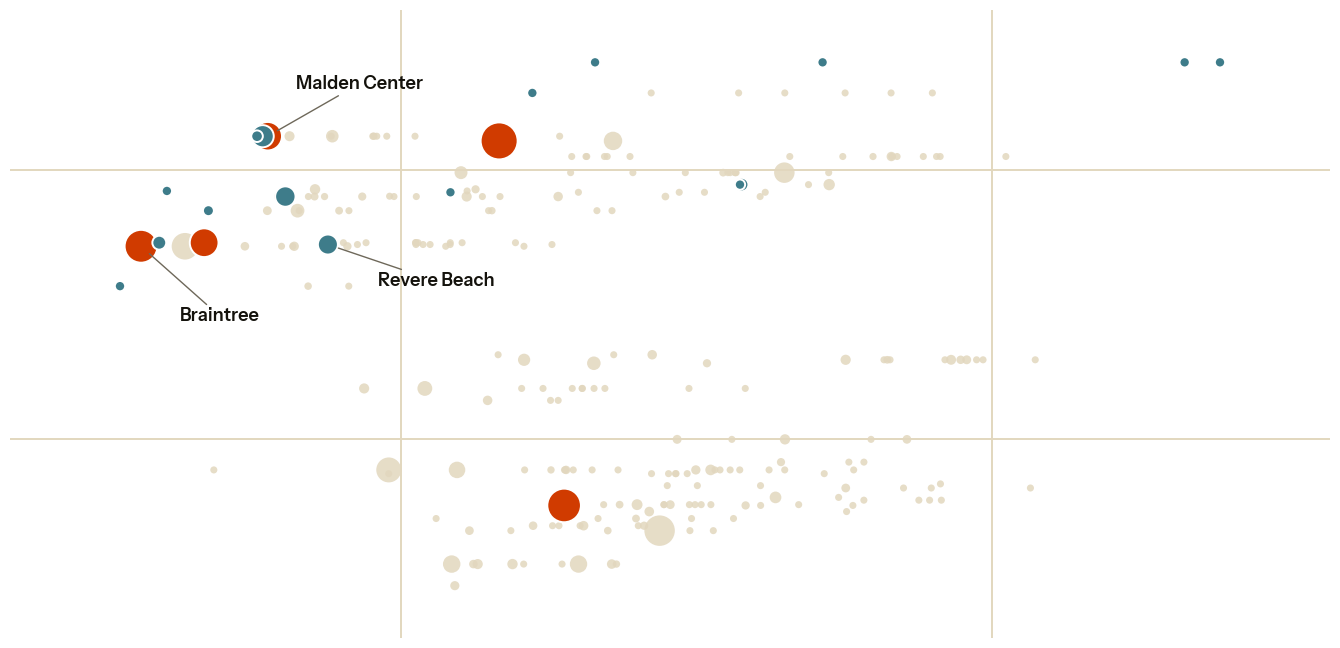

In [22]:
BOLD = mpl.font_manager.FontProperties(fname='fonts/InstrumentSans-SemiBold.ttf') \
    if os.path.exists('fonts/InstrumentSans-SemiBold.ttf') else None

fig, ax = plt.subplots(figsize=(13.2, 6.28))
d, f = site[~site.pareto], site[site.pareto]
ax.scatter(d.ppa, d.daily, s=np.clip(d.buildar_ac * 42, 26, 1800),
           color=FAINT, edgecolor='none', alpha=0.85, zorder=1)
for t, g in f.groupby('type'):
    ax.scatter(g.ppa, g.daily, s=np.clip(g.buildar_ac * 42, 55, 1800),
               color=TYPE_COLOR[t], edgecolor='white', lw=1.4, zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(which='both', length=0, labelbottom=False, labelleft=False)
# Decade lines only. The minor grid gave the picture a texture it did not need
# at the top of a page, and no axis text at all: the head crops this image to a
# banner and the listing card crops it again, so anything sitting near an edge
# gets cut in half. The caption carries what the axes mean.
ax.grid(True, which='major', color=FAINT, lw=1.4)
ax.grid(False, which='minor')
for side in ax.spines.values():
    side.set_visible(False)
ax.margins(0.1)

# The three that come first somewhere, and nothing else.
OFFSET = {'Malden Center': (20, 34), 'Braintree': (28, -54), 'Revere Beach': (36, -30)}
for nm in dict.fromkeys(winners.site):
    i = label[label == nm].index[0]
    station = site.station[i]  # the cover names the place, not the parcel
    ax.annotate(station, (site.ppa[i], site.daily[i]),
                textcoords='offset points', xytext=OFFSET[station],
                fontsize=13, color=INK, zorder=5,
                ha='left' if OFFSET[station][0] > 0 else 'right',
                fontproperties=BOLD,
                arrowprops=dict(arrowstyle='-', color=MUTE, lw=1.0,
                                shrinkA=0, shrinkB=8))

# The axes fill the figure exactly, so the decade lines run to all four edges
# and the picture has no border of its own. `bbox_inches='tight'` would trim
# back to the marks and undo that.
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
# bbox_inches=None explicitly. rcParams carries savefig.bbox='tight' for every
# other figure on the page, and leaving the argument off inherits it, which
# trims straight back to the marks and undoes the full-bleed axes above.
plt.savefig(f'{FIG}00-cover.png', dpi=300, bbox_inches=None, pad_inches=0)
plt.show()

## 15. What this version still cannot do

- **No demand-side demographics.** Nothing here describes who lives near these
  sites — income, tenure, household size — which is what anyone financing
  housing would underwrite on first.
- **Land value is assessed, not transacted.** Assessment lags the market and is
  set for taxation, not for sale.
- **The MAPC inventory is retail strip sites.** It is a good frame for
  redevelopment and it is not every developable parcel near a station.
- **The service data is one Saturday.** Enough to describe how the lines are
  built, not enough to say anything about reliability.
- **Station ridership is attributed to every site beside it.** Two parcels at
  the same station get the same demand figures, which is right for a half-mile
  catchment and wrong at the corner.
- **Nobody who works in any of these municipalities has seen this.** Every
  scenario is a position I wrote for them.

The 2024 version answered a question. This one maps out where the answer
changes, and says who would have to be asked to settle it.

In [23]:
site.to_csv('outputs/sites_scored_2026.csv', index=False) if os.path.isdir('outputs') else None
os.makedirs('outputs', exist_ok=True)
out = site[['sid', 'municipal', 'station', 'line', 'type', 'pareto', 'sitearea_a',
            'buildar_ac', 'ppa', 'daily', 'peak_share', 'jobs45tr', 'regipctile',
            'station_km', 'long', 'lat']].copy()
out = out.join(scores)
out.sort_values('No prior (all four equal)', ascending=False).to_csv('outputs/sites_scored_2026.csv', index=False)
top5.to_csv('outputs/scenario_top5.csv', index=False)
panel.to_csv('outputs/ridership_panel_2017_2025.csv')

# The case study shows this as a Leaflet map rather than a picture, so the
# analysis writes what that map needs: the rapid transit geometry as drawn
# lines, and every candidate parcel with the fields its popup reads. Written
# here so the map cannot drift away from the numbers in the charts.
geom = pd.read_csv(DATA + 'mbta_rapid_transit_shapes.csv')
lines_out = [{'line': ln, 'branch': br.split('|')[0],
              'pts': [[round(la, 5), round(lo, 5)]
                      for lo, la in zip(g['long'], g['lat'])]}
             for (ln, br), g in geom.groupby(['line', 'branch'], sort=False)]

wins = top5[top5['rank'] == 1].groupby('site').scenario.apply(list).to_dict()
eq_rank = scores['No prior (all four equal)'].rank(ascending=False).astype(int)
sites_out = [{'id': site.sid[i], 'code': site.code[i], 'station': site.station[i],
              'muni': site.municipal[i], 'line': site.line[i],
              'acres': round(float(site.buildar_ac[i]), 1),
              'ppa': int(round(site.ppa[i])), 'daily': int(round(site.daily[i])),
              'peak': round(float(site.peak_share[i]) * 100),
              'walk': round(float(site.station_km[i]), 2),
              'type': site.type[i], 'frontier': bool(site.pareto[i]),
              'named': bool(site.cited[i]) and not bool(site.pareto[i]),
              'rank': int(eq_rank[i]), 'wins': wins.get(label[i], []),
              'lat': round(float(site.lat[i]), 5),
              'lng': round(float(site.long[i]), 5)}
             for i in site.index]
sites_out.sort(key=lambda d: d['rank'])
with open('outputs/map.json', 'w', encoding='utf-8') as fh:
    json.dump({'lines': lines_out, 'sites': sites_out, 'total': len(sites_out),
               'frontier': int(site.pareto.sum())}, fh, separators=(',', ':'))
print('map.json:', len(lines_out), 'line branches,', len(sites_out), 'parcels')
print('written to outputs/:', sorted(os.listdir('outputs')))

map.json: 9 line branches, 251 parcels
written to outputs/: ['map.json', 'ridership_panel_2017_2025.csv', 'scenario_top5.csv', 'sites_scored_2026.csv']
